# **ANÁLISE EXPLORATÓRIA E VISUALIZAÇÃO DE DADOS**
### *Estudo de Caso: Turnover Funcionarios*
---



# **1. Instalação de bibliotecas**

In [87]:
# Apenas para bibliotecas que não estão incluídas por padrão no Google Colab; caso rode o código em outro ambiente, certifique-se de instalar as demais bibliotecas necessárias.
! pip install ydata_profiling

### **2. Carregamento de bibliotecas**

In [88]:
import pandas as pd                         # Manipulação de dados
import numpy as np                          # Realização de cálculos específicos
import matplotlib.pyplot as plt             # Visualização de dados
import seaborn as sns                       # Visualização de dados
from ydata_profiling import ProfileReport   # Análise exploratória automatizada

### **3. Leitura e inspeção inicial dos dados**

In [89]:
dados = pd.read_table('Estudo_Caso_1_Base_E_Dados.txt',   # Nome do arquivo
                      sep='\t',                    # Separador de colunas
                      decimal='.',                 # Separador de decimal
                      header=0)                    # Número da linha que contém o cabeçalho (se não houver, especificar: None)

In [90]:
# Inspeção das primeiras linhas
dados.head()

,id_funcionario,idade,sexo,nivel_formacao,area_atuacao,regime_trabalho,nivel_senioridade,tempo_empresa_meses,tempo_no_cargo_meses,promocao_12m,salario_mensal,perc_bonus_ultimo_ciclo,nota_avaliacao_desempenho,nota_enps,qtd_feedbacks_recebidos_6m,absenteismo_dias_6m,mudou_de_gestor_12m,tamanho_time,qtd_colegas_sairam_6m,turnover_voluntario_90d
0,EMP000001,36,M,pos_graduacao,dados,remoto,senior,17,12,nao,26300,0.0,1.9,7,4,1.0,nao,7,1,0
1,EMP000002,31,M,mestrado,design,remoto,junior,13,8,nao,4200,100.0,4.0,8,0,0.0,nao,5,1,0
2,EMP000003,30,F,pos_graduacao,negocios,presencial,gerente,20,12,sim,33900,100.0,4.5,4,0,0.0,nao,7,0,0
3,EMP000004,30,M,pos_graduacao,engenharia,presencial,pleno,28,21,nao,15000,0.0,2.4,8,3,0.0,nao,3,0,0
4,EMP000005,48,M,superior,dados,hibrido,senior,21,13,nao,23700,100.0,3.9,7,4,2.0,nao,5,0,0


In [91]:
# Quantidade de linhas e colunas
dados.shape

(12000, 20)

In [92]:
# Tipos das colunas
dados.dtypes

,0
id_funcionario,object
idade,int64
sexo,object
nivel_formacao,object
area_atuacao,object
regime_trabalho,object
nivel_senioridade,object
tempo_empresa_meses,int64
tempo_no_cargo_meses,int64
promocao_12m,object


### **4. Transformações de dados**

In [93]:
# Nesta base de dados, não foram realizadas transformações de dados (criação de colunas calculadas, conversão de tipos etc.)

### **5. Análises de unicidade e preenchimento**

*Contabilização da quantidade de valores duplicados na chave*

In [94]:
# Altere o nome do(s) campo(s) chave, conforme necessário
dados[['id_funcionario']].duplicated().sum()

np.int64(0)

*O retorno demonstra que existe unicidade na tabela de ID dos Funcionarios.*

In [95]:
dados.isna().sum()

,0
id_funcionario,0
idade,0
sexo,0
nivel_formacao,0
area_atuacao,0
regime_trabalho,0
nivel_senioridade,0
tempo_empresa_meses,0
tempo_no_cargo_meses,0
promocao_12m,0


*Contabilização da porcentagem de valores ausentes em cada variável*

In [96]:
dados.isnull().mean().round(3) * 100

,0
id_funcionario,0.0
idade,0.0
sexo,0.0
nivel_formacao,0.0
area_atuacao,0.0
regime_trabalho,0.0
nivel_senioridade,0.0
tempo_empresa_meses,0.0
tempo_no_cargo_meses,0.0
promocao_12m,0.0


## *Visualização dos dados nulos da coluna "perc_bonus_ultimo_ciclo"*

In [97]:
dados[dados['perc_bonus_ultimo_ciclo'].isna()]

,id_funcionario,idade,sexo,nivel_formacao,area_atuacao,regime_trabalho,nivel_senioridade,tempo_empresa_meses,tempo_no_cargo_meses,promocao_12m,salario_mensal,perc_bonus_ultimo_ciclo,nota_avaliacao_desempenho,nota_enps,qtd_feedbacks_recebidos_6m,absenteismo_dias_6m,mudou_de_gestor_12m,tamanho_time,qtd_colegas_sairam_6m,turnover_voluntario_90d
10,EMP000011,26,F,superior,negocios,presencial,junior,5,1,nao,6100,NaN,3.9,4,1,5.0,nao,7,3,1
38,EMP000039,29,M,pos_graduacao,operacoes,presencial,junior,1,1,nao,4200,NaN,3.7,4,1,NaN,nao,11,2,1
157,EMP000158,20,F,superior,dados,hibrido,junior,2,1,nao,6000,NaN,2.4,3,4,NaN,nao,8,2,0
203,EMP000204,24,F,superior,negocios,hibrido,junior,4,4,nao,5900,NaN,3.6,5,0,3.0,sim,7,0,0
259,EMP000260,31,M,mestrado,engenharia,remoto,junior,3,3,nao,5900,NaN,3.3,5,2,1.0,nao,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,EMP011586,28,F,mestrado,dados,remoto,junior,3,1,nao,6100,NaN,3.8,9,1,0.0,nao,5,1,0
11622,EMP011623,33,F,pos_graduacao,engenharia,hibrido,junior,3,2,nao,5800,NaN,1.9,8,1,1.0,nao,5,1,0
11624,EMP011625,41,M,mestrado,engenharia,hibrido,junior,5,2,nao,6300,NaN,3.3,5,2,1.0,sim,5,4,0
11719,EMP011720,29,F,pos_graduacao,operacoes,presencial,junior,5,4,nao,3800,NaN,2.7,5,3,0.0,sim,12,1,0


*Essa tabela demonstra que todos os funcionários com valores nulo no "Percentual de bônus recebido no último ciclo de avaliação" são colaboradores no nível de senioridade "Junior" e tempo de empresa em meses menor que 6.*

In [98]:
dados[(dados['nivel_senioridade'] == "junior") & (dados["tempo_empresa_meses"] < 6)]

,id_funcionario,idade,sexo,nivel_formacao,area_atuacao,regime_trabalho,nivel_senioridade,tempo_empresa_meses,tempo_no_cargo_meses,promocao_12m,salario_mensal,perc_bonus_ultimo_ciclo,nota_avaliacao_desempenho,nota_enps,qtd_feedbacks_recebidos_6m,absenteismo_dias_6m,mudou_de_gestor_12m,tamanho_time,qtd_colegas_sairam_6m,turnover_voluntario_90d
10,EMP000011,26,F,superior,negocios,presencial,junior,5,1,nao,6100,NaN,3.9,4,1,5.0,nao,7,3,1
38,EMP000039,29,M,pos_graduacao,operacoes,presencial,junior,1,1,nao,4200,NaN,3.7,4,1,NaN,nao,11,2,1
157,EMP000158,20,F,superior,dados,hibrido,junior,2,1,nao,6000,NaN,2.4,3,4,NaN,nao,8,2,0
203,EMP000204,24,F,superior,negocios,hibrido,junior,4,4,nao,5900,NaN,3.6,5,0,3.0,sim,7,0,0
259,EMP000260,31,M,mestrado,engenharia,remoto,junior,3,3,nao,5900,NaN,3.3,5,2,1.0,nao,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,EMP011586,28,F,mestrado,dados,remoto,junior,3,1,nao,6100,NaN,3.8,9,1,0.0,nao,5,1,0
11622,EMP011623,33,F,pos_graduacao,engenharia,hibrido,junior,3,2,nao,5800,NaN,1.9,8,1,1.0,nao,5,1,0
11624,EMP011625,41,M,mestrado,engenharia,hibrido,junior,5,2,nao,6300,NaN,3.3,5,2,1.0,sim,5,4,0
11719,EMP011720,29,F,pos_graduacao,operacoes,presencial,junior,5,4,nao,3800,NaN,2.7,5,3,0.0,sim,12,1,0


In [99]:
dados[(dados['nivel_senioridade'] == "junior") & (dados["tempo_empresa_meses"] < 6)][['nivel_senioridade', 'tempo_empresa_meses', 'perc_bonus_ultimo_ciclo']]

,nivel_senioridade,tempo_empresa_meses,perc_bonus_ultimo_ciclo
10,junior,5,NaN
38,junior,1,NaN
157,junior,2,NaN
203,junior,4,NaN
259,junior,3,NaN
...,...,...,...
11585,junior,3,NaN
11622,junior,3,NaN
11624,junior,5,NaN
11719,junior,5,NaN


In [100]:
dados[(dados['nivel_senioridade'] == "junior") & (dados["tempo_empresa_meses"] >= 6)][['nivel_senioridade', 'tempo_empresa_meses', 'perc_bonus_ultimo_ciclo']]

,nivel_senioridade,tempo_empresa_meses,perc_bonus_ultimo_ciclo
1,junior,13,100.0
11,junior,34,100.0
16,junior,59,100.0
18,junior,31,100.0
27,junior,39,100.0
...,...,...,...
11974,junior,64,200.0
11977,junior,11,100.0
11982,junior,63,100.0
11986,junior,24,100.0


*Ao comparar ambas as tabelas foi possível visualizar que apenas os funcionários com senioridade "Junior" e tempo de empresa em meses menor que 6 meses possuem o Percentual de bônus recebido no último ciclo de avaliação como valor inválido.*


## *Visualização dos dados nulos da coluna "absenteismo_dias_6m"*

In [101]:
dados[dados['absenteismo_dias_6m'].isna()]

,id_funcionario,idade,sexo,nivel_formacao,area_atuacao,regime_trabalho,nivel_senioridade,tempo_empresa_meses,tempo_no_cargo_meses,promocao_12m,salario_mensal,perc_bonus_ultimo_ciclo,nota_avaliacao_desempenho,nota_enps,qtd_feedbacks_recebidos_6m,absenteismo_dias_6m,mudou_de_gestor_12m,tamanho_time,qtd_colegas_sairam_6m,turnover_voluntario_90d
32,EMP000033,28,F,pos_graduacao,produto,presencial,senior,1,1,nao,19700,200.0,2.9,4,6,NaN,nao,7,0,0
35,EMP000036,40,M,pos_graduacao,dados,remoto,senior,2,2,nao,16000,0.0,3.9,9,4,NaN,nao,10,0,0
38,EMP000039,29,M,pos_graduacao,operacoes,presencial,junior,1,1,nao,4200,NaN,3.7,4,1,NaN,nao,11,2,1
83,EMP000084,30,M,pos_graduacao,engenharia,hibrido,senior,1,1,nao,24100,100.0,2.9,4,4,NaN,nao,5,0,0
116,EMP000117,27,F,superior,negocios,presencial,pleno,2,2,nao,10000,100.0,3.2,6,2,NaN,nao,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11724,EMP011725,33,M,pos_graduacao,design,hibrido,pleno,2,1,nao,12100,0.0,2.4,4,2,NaN,nao,8,1,0
11753,EMP011754,39,M,pos_graduacao,negocios,hibrido,senior,1,1,nao,18000,100.0,4.1,3,4,NaN,nao,7,4,0
11755,EMP011756,33,M,superior,produto,remoto,gerente,2,2,nao,24500,100.0,4.8,3,9,NaN,nao,6,2,0
11814,EMP011815,38,M,superior,design,hibrido,pleno,2,1,nao,9300,100.0,3.5,5,2,NaN,nao,11,3,0


*Essa tabela demonstra que todos os funcionários com valores nulo no "Número de dias de ausência não planejada nos últimos 6 meses." são colaboradores com tempo de empresa em meses menor que 2.*

In [102]:
dados[(dados["tempo_empresa_meses"] <= 2)][['tempo_empresa_meses', 'absenteismo_dias_6m']]

,tempo_empresa_meses,absenteismo_dias_6m
32,1,NaN
35,2,NaN
38,1,NaN
83,1,NaN
116,2,NaN
...,...,...
11724,2,NaN
11753,1,NaN
11755,2,NaN
11814,2,NaN


In [103]:
dados[(dados["tempo_empresa_meses"] > 2)][['tempo_empresa_meses', 'absenteismo_dias_6m']]

,tempo_empresa_meses,absenteismo_dias_6m
0,17,1.0
1,13,0.0
2,20,0.0
3,28,0.0
4,21,2.0
...,...,...
11995,39,0.0
11996,15,0.0
11997,11,0.0
11998,14,0.0


*Ao comparar ambas as tabelas foi possível visualizar que a hipótese estava correta, apenas colaboradores com tempo de empresa menor que 2 (em meses) estão com o valor vazio em "Número de dias de ausência não planejada nos últimos 6 meses."*

In [104]:
# Altererando as variáveis NaN ou vazias por 0
dados['perc_bonus_ultimo_ciclo'] = dados['perc_bonus_ultimo_ciclo'].fillna(0)
dados['absenteismo_dias_6m'] = dados['absenteismo_dias_6m'].fillna(0)

### **6. Análise univariada**

In [105]:
#Variáveis para criação dos gráficos bivariáveis
graph_id = dados['id_funcionario']
graph_idade = dados['idade']
graph_sexo = dados['sexo']
graph_formacao = dados['nivel_formacao']
graph_area_atuacao = dados['area_atuacao']
graph_regime_trabalho = dados['regime_trabalho']
graph_nivel_senioridade = dados['nivel_senioridade']
graph_tempo_empresa_meses = dados['tempo_empresa_meses']
graph_tempo_no_cargo_meses = dados['tempo_no_cargo_meses']
graph_promocao = dados['promocao_12m']
graph_salario = dados['salario_mensal']
graph_bonus = dados['perc_bonus_ultimo_ciclo']
graph_nota_avaliacao_desempenho = dados['nota_avaliacao_desempenho']
graph_nota_enps = dados['nota_enps']
graph_qtd_feedbacks_recebidos = dados['qtd_feedbacks_recebidos_6m']
graph_absenteismo_dias = dados['absenteismo_dias_6m']
graph_mudou_de_gestor = dados['mudou_de_gestor_12m']
graph_tamanho_time = dados['tamanho_time']
graph_qtd_colegas_sairam_6m = dados['qtd_colegas_sairam_6m']
graph_turnover = dados['turnover_voluntario_90d']

## Idade

In [106]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['idade']
# Altere para os pontos de corte desejados (o mínimo e o máximo devem estar abrangidos na lista)
pontos_corte = [var_quanti.min(), 25, 35, 45, 55, var_quanti.max()]
# Criação de vetor representando a variável dividida em faixas
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)

In [107]:
# Tabela de frequências absolutas
var_quanti_faixas.value_counts(dropna=False, sort=False)

,count
idade,
"(19.999, 25.0]",1378
"(25.0, 35.0]",6587
"(35.0, 45.0]",3065
"(45.0, 55.0]",802
"(55.0, 63.0]",168


In [108]:
# Tabela de frequências relativas, no formato de porcentagens
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
idade,
"(19.999, 25.0]",11.5
"(25.0, 35.0]",54.9
"(35.0, 45.0]",25.5
"(45.0, 55.0]",6.7
"(55.0, 63.0]",1.4


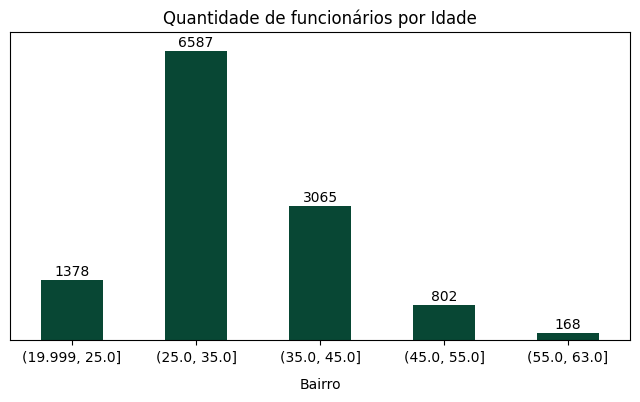

In [109]:
# Tabela de frequências
tab_abs = var_quanti_faixas.value_counts(dropna=False).sort_index()

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
tab_abs.plot(kind='bar', color='#084734')

# Título do gráfico
plt.title("Quantidade de funcionários por Idade")

# Limites do eixo vertical
plt.ylim(0, 7000)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Bairro', labelpad=10)

# Rótulos sobre as barras
for i, v in enumerate(tab_abs):
    plt.text(i, v + 100, str(v), ha='center')

plt.show()

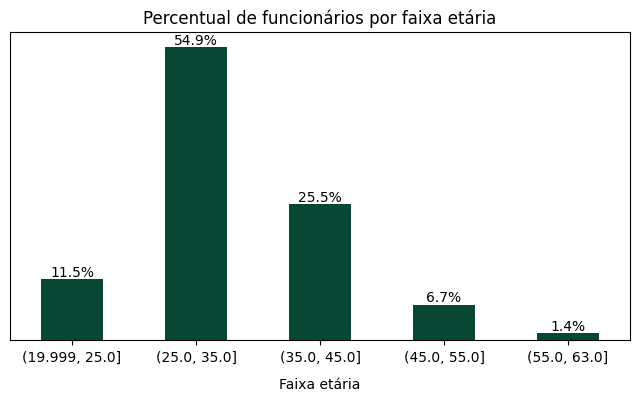

In [110]:
# Tabela de frequências (%)
tab_pct = (
    var_quanti_faixas
    .value_counts(dropna=False, normalize=True)
    .sort_index()
    * 100
)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
tab_pct.plot(kind='bar', color='#084734')

# Título do gráfico
plt.title("Percentual de funcionários por faixa etária")

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Faixa etária', labelpad=10)

# Rótulos sobre as barras
for i, v in enumerate(tab_pct):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.show()

## Sexo

In [111]:
# Altere para o nome da variável qualitativa desejada
var_quali = dados['sexo']
var_quali.value_counts(dropna=False)

,count
sexo,
M,7007
F,4993


In [112]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
sexo,
M,58.4
F,41.6


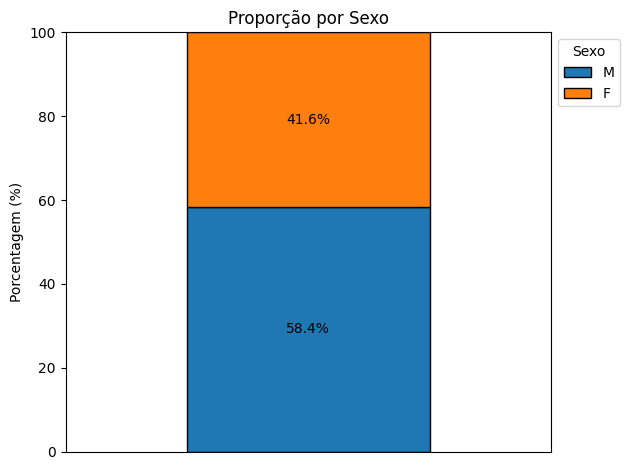

In [113]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100
df_plot = ax.to_frame().T

# Cria o gráfico de barras empilhadas
ax = df_plot.plot(kind="bar", stacked=True, edgecolor="black")

# Percorre os segmentos das barras para adicionar os rótulos de dados
for container in ax.containers:
    # Extrai o valor do percentual
    value = container.datavalues[0]
    # Rótula apenas segmentos maiores que 0% para evitar sobreposição
    if value > 0:
        ax.bar_label(container, labels=[f"{value:.1f}%"], label_type="center")

# Título do gráfico
plt.title("Proporção por Sexo")

# Título do eixo vertical e espaçamento
plt.ylabel("Porcentagem (%)")

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks([])

# Limites do eixo vertical
plt.ylim(0, 100)

# Legenda fora da área de plotagem
plt.legend(title="Sexo", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

# Exibe o gráfico finalizado
plt.show()

## Nível de Formação

In [114]:
var_quali = dados['nivel_formacao']
var_quali.value_counts(dropna=False)
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
nivel_formacao,
superior,44.5
pos_graduacao,36.2
mestrado,15.4
doutorado,4.0


In [115]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
nivel_formacao,
superior,44.5
pos_graduacao,36.2
mestrado,15.4
doutorado,4.0


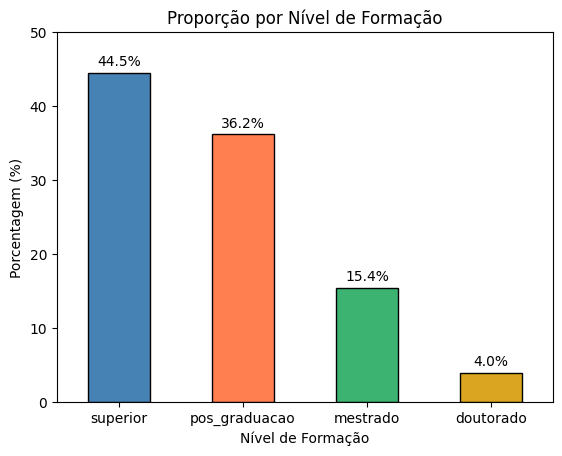

In [116]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100

# Cria o gráfico de barras padrão (cada categoria tem sua própria coluna)
ax = ax.plot(kind="bar", edgecolor="black", color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'darkblue', 'orange'])

# Percorre as barras para adicionar os rótulos de dados no topo
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

# Título do gráfico
plt.title("Proporção por Nível de Formação")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Título do eixo horizontal
plt.xlabel("Nível de Formação")
plt.xticks(rotation=0)  # Mantém os nomes das categorias na horizontal
plt.ylim(0, 50)        # Margem extra no topo para o texto não cortar

# Exibe o gráfico finalizado
plt.show()

## Área de Atuação

In [117]:
var_quali = dados['area_atuacao']
var_quali.value_counts(dropna=False)

,count
area_atuacao,
engenharia,4186
produto,2175
dados,2012
negocios,1479
operacoes,1175
design,973


In [118]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
area_atuacao,
engenharia,34.9
produto,18.1
dados,16.8
negocios,12.3
operacoes,9.8
design,8.1


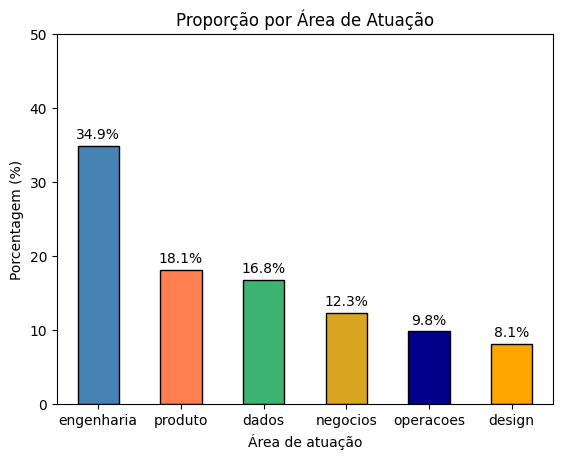

In [119]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100

# Cria o gráfico de barras padrão (cada categoria tem sua própria coluna)
ax = ax.plot(kind="bar", edgecolor="black", color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'darkblue', 'orange'])

# Percorre as barras para adicionar os rótulos de dados no topo
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

# Título do gráfico
plt.title("Proporção por Área de Atuação")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Título do eixo horizontal
plt.xlabel("Área de atuação")
plt.xticks(rotation=0)  # Mantém os nomes das categorias na horizontal
plt.ylim(0, 50)        # Margem extra no topo para o texto não cortar

# Exibe o gráfico finalizado
plt.show()

## Nível de Senioridade

In [120]:
# Tabela de frequências relativas, no formato de porcentagens, com ordenação de categorias (obs.: apenas se a variável for ordinal)
var_quali = dados['nivel_senioridade']
categorias = ['junior', 'pleno', 'senior', 'gerente', 'gerente sr./diretor']
var_ordenada = pd.Categorical(var_quali, categories=categorias, ordered=True)
pd.Series(var_ordenada).value_counts(dropna=False).reindex(var_ordenada.categories)

,count
junior,2302
pleno,3629
senior,3694
gerente,1542
gerente sr./diretor,833


In [121]:
pd.Series(var_ordenada).value_counts(dropna=False, normalize=True).reindex(var_ordenada.categories).round(3) * 100

,proportion
junior,19.2
pleno,30.2
senior,30.8
gerente,12.8
gerente sr./diretor,6.9


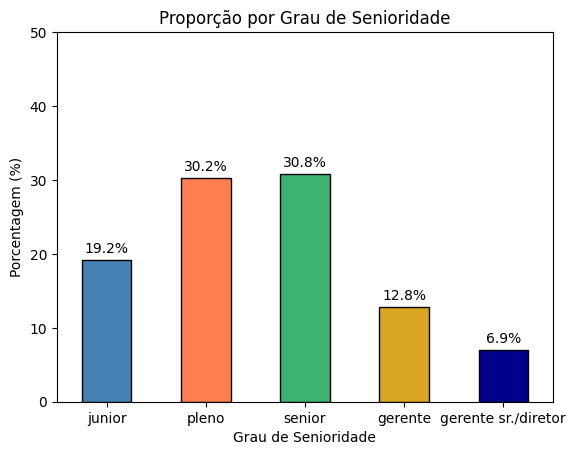

In [122]:
# 1. Ordenando por categorias
categorias = ['junior', 'pleno', 'senior', 'gerente', 'gerente sr./diretor']
dados['nivel_senioridade'] = pd.Categorical(
    dados['nivel_senioridade'],
    categories=categorias,
    ordered=True
)

# 2. CALCULE A PORCENTAGEM USANDO .reindex()
# Isso força o Pandas a seguir a ordem da lista 'categorias'
ax = dados['nivel_senioridade'].value_counts(normalize=True).reindex(categorias) * 100

# 3. Plote o gráfico
ax = ax.plot(kind="bar", edgecolor="black", color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'darkblue'])

# O resto do seu código permanece igual
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3)

plt.title("Proporção por Grau de Senioridade")
plt.ylabel("Porcentagem (%)")
plt.xlabel("Grau de Senioridade")
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.show()

## Regime de Trabalho

In [123]:
# Altere para o nome da variável qualitativa desejada
var_quali = dados['regime_trabalho']
var_quali.value_counts(dropna=False)

,count
regime_trabalho,
hibrido,4833
remoto,4581
presencial,2586


In [124]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
regime_trabalho,
hibrido,40.3
remoto,38.2
presencial,21.6


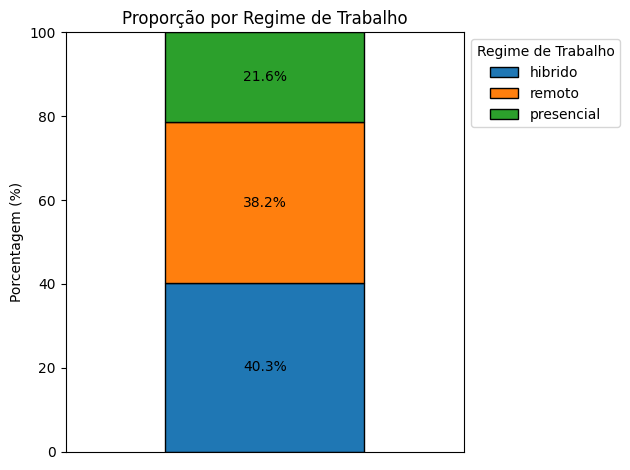

In [125]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100
df_plot = ax.to_frame().T

# Cria o gráfico de barras empilhadas
ax = df_plot.plot(kind="bar", stacked=True, edgecolor="black")

# Percorre os segmentos das barras para adicionar os rótulos de dados
for container in ax.containers:
    # Extrai o valor do percentual
    value = container.datavalues[0]
    # Rótula apenas segmentos maiores que 0% para evitar sobreposição
    if value > 0:
        ax.bar_label(container, labels=[f"{value:.1f}%"], label_type="center")

# Título do gráfico
plt.title("Proporção por Regime de Trabalho")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks([])

# Limites do eixo vertical
plt.ylim(0, 100)

# Legenda fora da área de plotagem
plt.legend(title="Regime de Trabalho", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

# Exibe o gráfico finalizado
plt.show()

## Promoção nos 12 últimos meses

In [126]:
var_quali = dados['promocao_12m']
var_quali.value_counts(dropna=False)

,count
promocao_12m,
nao,8484
sim,3516


In [127]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
promocao_12m,
nao,70.7
sim,29.3


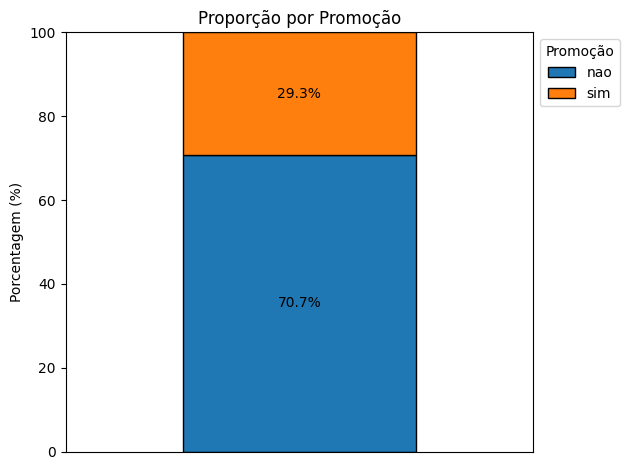

In [128]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100
df_plot = ax.to_frame().T

# Cria o gráfico de barras empilhadas
ax = df_plot.plot(kind="bar", stacked=True, edgecolor="black")

# Percorre os segmentos das barras para adicionar os rótulos de dados
for container in ax.containers:
    # Extrai o valor do percentual
    value = container.datavalues[0]
    # Rótula apenas segmentos maiores que 0% para evitar sobreposição
    if value > 0:
        ax.bar_label(container, labels=[f"{value:.1f}%"], label_type="center")

# Título do gráfico
plt.title("Proporção por Promoção")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks([])

# Limites do eixo vertical
plt.ylim(0, 100)

# Legenda fora da área de plotagem
plt.legend(title="Promoção", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

# Exibe o gráfico finalizado
plt.show()

## Mudou de Gestor nos 12 últimos meses

In [129]:
var_quali = dados['mudou_de_gestor_12m']
var_quali.value_counts(dropna=False)

,count
mudou_de_gestor_12m,
nao,8738
sim,3262


In [130]:
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
mudou_de_gestor_12m,
nao,72.8
sim,27.2


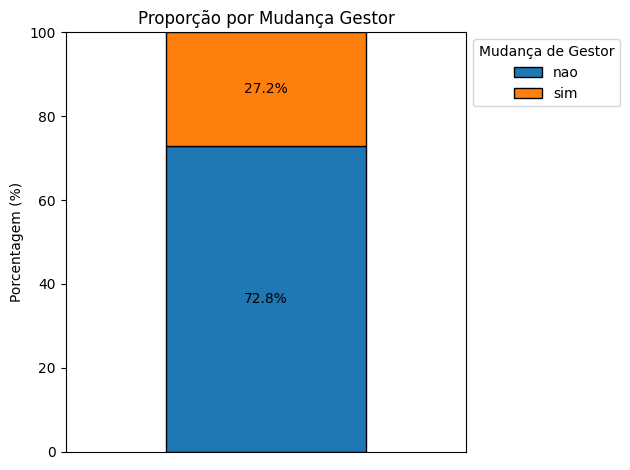

In [131]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100
df_plot = ax.to_frame().T

# Cria o gráfico de barras empilhadas
ax = df_plot.plot(kind="bar", stacked=True, edgecolor="black")

# Percorre os segmentos das barras para adicionar os rótulos de dados
for container in ax.containers:
    # Extrai o valor do percentual
    value = container.datavalues[0]
    # Rótula apenas segmentos maiores que 0% para evitar sobreposição
    if value > 0:
        ax.bar_label(container, labels=[f"{value:.1f}%"], label_type="center")

# Título do gráfico
plt.title("Proporção por Mudança Gestor")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks([])

# Limites do eixo vertical
plt.ylim(0, 100)

# Legenda fora da área de plotagem
plt.legend(title="Mudança de Gestor", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

# Exibe o gráfico finalizado
plt.show()

## Turnover voluntário nos últimos 90 dias

In [132]:
var_quali = dados['turnover_voluntario_90d']
var_quali.value_counts(dropna=False)


,count
turnover_voluntario_90d,
0,11179
1,821


In [133]:
var_quali.value_counts(dropna=False, normalize=True)
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
turnover_voluntario_90d,
0,93.2
1,6.8


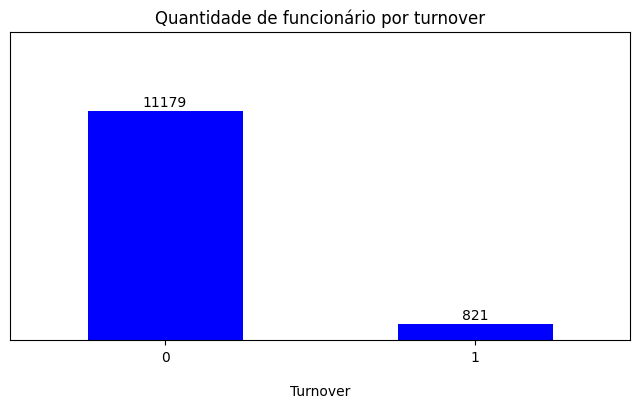

In [134]:
var = dados['turnover_voluntario_90d']

# Tabela de frequências
tab_abs = var.value_counts(dropna=False).sort_index()

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
tab_abs.plot(kind='bar', color='blue')

# Título do gráfico
plt.title("Quantidade de funcionário por turnover")

# Limites do eixo vertical
plt.ylim(0, 15000)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Turnover', labelpad=15)

# Rótulos sobre as barras
for i, v in enumerate(tab_abs):
    plt.text(i, v + 200, str(v), ha='center')

plt.show()

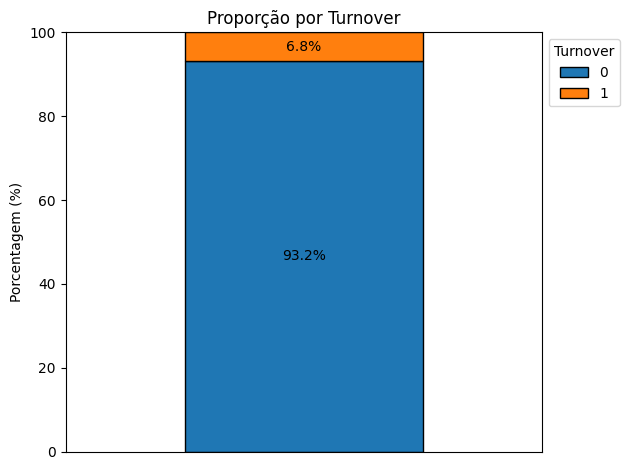

In [135]:
# Calcula as porcentagens
ax = var_quali.value_counts(normalize=True).round(3) * 100
df_plot = ax.to_frame().T

# Cria o gráfico de barras empilhadas
ax = df_plot.plot(kind="bar", stacked=True, edgecolor="black")

# Percorre os segmentos das barras para adicionar os rótulos de dados
for container in ax.containers:
    # Extrai o valor do percentual
    value = container.datavalues[0]
    # Rótula apenas segmentos maiores que 0% para evitar sobreposição
    if value > 0:
        ax.bar_label(container, labels=[f"{value:.1f}%"], label_type="center")

# Título do gráfico
plt.title("Proporção por Turnover")

# Título do eixo vertical
plt.ylabel("Porcentagem (%)")

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks([])

# Limites do eixo vertical
plt.ylim(0, 100)

# Legenda fora da área de plotagem
plt.legend(title="Turnover", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

# Exibe o gráfico finalizado
plt.show()

## *Tabela de frequências para variável quantitativa*

In [136]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['idade']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 28, 32, 38, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
idade,
"(19.999, 28.0]",28.6
"(28.0, 32.0]",23.6
"(32.0, 38.0]",25.4
"(38.0, 63.0]",22.4


In [137]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['tempo_empresa_meses']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 14, 28, 46, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
tempo_empresa_meses,
"(0.999, 14.0]",25.6
"(14.0, 28.0]",24.6
"(28.0, 46.0]",25.3
"(46.0, 120.0]",24.4


In [138]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['tempo_no_cargo_meses']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 8, 17, 30, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
tempo_no_cargo_meses,
"(0.999, 8.0]",25.7
"(8.0, 17.0]",25.6
"(17.0, 30.0]",25.0
"(30.0, 119.0]",23.7


In [139]:
var_quanti = dados['salario_mensal']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 10000, 15000, 23000, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
salario_mensal,
"(2999.999, 10000.0]",28.7
"(10000.0, 15000.0]",22.6
"(15000.0, 23000.0]",24.8
"(23000.0, 67300.0]",23.9


In [140]:
var_quanti = dados['qtd_feedbacks_recebidos_6m']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 2, 3, 5, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
qtd_feedbacks_recebidos_6m,
"(-0.001, 2.0]",33.6
"(2.0, 3.0]",17.1
"(3.0, 5.0]",26.4
"(5.0, 16.0]",22.9


In [141]:
var_quanti = dados['tamanho_time']
var_quanti.value_counts(dropna=False)
pontos_corte = [var_quanti.min(), 5, 10, 13, var_quanti.max()]
var_quanti_faixas = pd.cut(var_quanti, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
var_quanti_faixas.value_counts(dropna=False, sort=False, normalize=True).round(3) * 100

,proportion
tamanho_time,
"(2.999, 5.0]",30.5
"(5.0, 10.0]",59.8
"(10.0, 13.0]",8.4
"(13.0, 19.0]",1.4


## *Medidas resumo*

In [142]:
colunas_quantitativas = [
    'idade', 'tempo_empresa_meses', 'tempo_no_cargo_meses',
    'salario_mensal', 'qtd_feedbacks_recebidos_6m', 'perc_bonus_ultimo_ciclo',
    'absenteismo_dias_6m', 'tamanho_time', 'qtd_colegas_sairam_6m'
]

In [143]:
# Medidas principais via "describe": média, desvio padrão, mínimo, quartis e máximo
print("--- Medidas principais via 'describe' ---")
display(dados[colunas_quantitativas].describe().round(2))

--- Medidas principais via 'describe' ---


,idade,tempo_empresa_meses,tempo_no_cargo_meses,salario_mensal,qtd_feedbacks_recebidos_6m,perc_bonus_ultimo_ciclo,absenteismo_dias_6m,tamanho_time,qtd_colegas_sairam_6m
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,33.59,32.31,20.90,17110.34,3.85,85.09,1.03,7.01,1.22
std,7.66,22.25,16.58,10270.25,2.51,72.60,1.71,2.59,1.56
min,20.00,1.00,1.00,3000.00,0.00,0.00,0.00,3.00,0.00
25%,28.00,14.00,8.00,9300.00,2.00,0.00,0.00,5.00,0.00
50%,32.00,28.00,17.00,14650.00,3.00,100.00,0.00,7.00,1.00
75%,38.00,46.00,30.00,22500.00,5.00,100.00,1.00,9.00,2.00
max,63.00,120.00,119.00,67300.00,16.00,200.00,15.00,19.00,10.00


# **7. Análise de valores atípicos**

## Idade

In [144]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['idade']
var_quanti.describe()

,idade
count,12000.000000
mean,33.588250
std,7.657388
min,20.000000
25%,28.000000
50%,32.000000
75%,38.000000
max,63.000000


In [145]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23

In [146]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,
       63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,
       63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 62, 62, 62, 62, 62,
       62, 62, 62, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 60,
       60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 59,
       59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 58, 58, 58,
       58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 57,
       57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 55, 55,
       55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55,
       55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54

## Tempo Empresa em Meses

In [147]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['tempo_empresa_meses']
var_quanti.describe()

,tempo_empresa_meses
count,12000.000000
mean,32.310500
std,22.246989
min,1.000000
25%,14.000000
50%,28.000000
75%,46.000000
max,120.000000


In [148]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [149]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120,
       120, 120, 120, 120, 120, 120, 120, 120, 119, 118, 118, 118, 117,
       117, 117, 117, 117, 117, 117, 115, 115, 114, 114, 114, 114, 113,
       113, 113, 113, 113, 113, 113, 112, 112, 112, 112, 111, 110, 110,
       109, 109, 109, 108, 108, 108, 108, 107, 106, 106, 105, 105, 105,
       105, 105, 104, 104, 104, 104, 104, 104, 103, 103, 103, 103, 103,
       103, 103, 103, 103, 103, 103, 103, 103, 102, 102, 102, 102, 102,
       102, 102, 101, 101, 101, 101, 101, 101, 101, 101, 101, 100, 100,
       100, 100, 100, 100, 100, 100, 100,  99,  99,  99,  99,  99,  99,
        99,  99,  98,  98,  98,  98,  98,  98,  98,  98,  98,  98,  98,
        98,  98,  97,  97,  97,  97,  97,  97,  96,  96,  96,  96,  96,
        96,  96,  96,  95,  95,  95,  95,  95,  95,  95,  95,  95,  95,
        94,  94,  94,  94,  94,  93,  93,  93,  93,  93,  93,  93,  93,
        93,  93,  93,  93,  93,  93,  92,  92,  92,  92,  92,  9

## Tempo No Cargo Meses

In [150]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['tempo_no_cargo_meses']
var_quanti.describe()

,tempo_no_cargo_meses
count,12000.000000
mean,20.899167
std,16.582011
min,1.000000
25%,8.000000
50%,17.000000
75%,30.000000
max,119.000000


In [151]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [152]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([119, 114, 113, 109, 107, 107, 106, 106, 106, 104, 104, 102, 101,
       100,  98,  97,  96,  96,  96,  96,  96,  96,  95,  95,  95,  94,
        94,  93,  93,  93,  92,  91,  91,  91,  91,  91,  91,  90,  90,
        89,  89,  89,  88,  88,  87,  87,  86,  86,  86,  85,  85,  85,
        85,  85,  85,  85,  85,  85,  84,  84,  84,  84,  83,  83,  83,
        83,  82,  82,  82,  82,  82,  82,  82,  82,  82,  81,  81,  81,
        81,  81,  81,  81,  80,  79,  79,  79,  79,  79,  79,  79,  79,
        78,  78,  78,  78,  78,  77,  77,  77,  77,  77,  76,  76,  76,
        76,  76,  75,  75,  75,  75,  75,  75,  75,  75,  75,  75,  75,
        75,  74,  74,  74,  74,  74,  74,  74,  74,  74,  74,  74,  74,
        74,  74,  74,  73,  73,  73,  73,  73,  73,  73,  73,  73,  73,
        73,  73,  72,  72,  72,  72,  72,  72,  72,  72,  72,  72,  71,
        71,  71,  71,  71,  71,  71,  71,  71,  71,  71,  71,  71,  71,
        71,  71,  70,  70,  70,  70,  70,  70,  70,  70,  70,  6

## Salário Mensal

In [153]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['salario_mensal']
var_quanti.describe()

,salario_mensal
count,12000.000000
mean,17110.341667
std,10270.251558
min,3000.000000
25%,9300.000000
50%,14650.000000
75%,22500.000000
max,67300.000000


In [154]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([3000, 3000, 3000, 3000, 3000, 3000, 3000, 3100, 3100, 3100, 3200,
       3200, 3200, 3200, 3300, 3300, 3300, 3300, 3300, 3400, 3400, 3400,
       3400, 3400, 3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500,
       3600, 3600, 3600, 3600, 3600, 3600, 3700, 3700, 3700, 3700, 3700,
       3700, 3700, 3700, 3700, 3700, 3700, 3700, 3700, 3700, 3700, 3800,
       3800, 3800, 3800, 3800, 3800, 3800, 3800, 3800, 3800, 3800, 3800,
       3800, 3800, 3800, 3800, 3900, 3900, 3900, 3900, 3900, 3900, 3900,
       3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900,
       3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900, 3900,
       3900, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000,
       4000, 4000, 4000, 4000, 4000, 4100, 4100, 4100, 4100, 4100, 4100,
       4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100,
       4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100, 4100,
       4100, 4100, 4100, 4100, 4100, 4100, 4100, 41

In [155]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([67300, 63200, 62600, 61700, 61200, 60700, 59800, 59700, 59300,
       59200, 59200, 58800, 58600, 58500, 57900, 57700, 57000, 56800,
       56700, 56600, 56100, 55700, 55600, 55500, 55400, 55300, 55200,
       54900, 54800, 54800, 54700, 54600, 54400, 54400, 54300, 54200,
       54200, 54200, 54100, 54000, 54000, 53800, 53600, 53500, 53400,
       53300, 53300, 53200, 53200, 53100, 52800, 52700, 52400, 52200,
       52200, 52100, 52000, 52000, 51900, 51800, 51600, 51400, 51400,
       51000, 50900, 50600, 50300, 50200, 50200, 50200, 50100, 50000,
       50000, 50000, 49900, 49800, 49800, 49800, 49700, 49600, 49600,
       49600, 49600, 49600, 49500, 49400, 49400, 49200, 49200, 49100,
       49100, 48900, 48800, 48800, 48700, 48700, 48700, 48500, 48300,
       48300, 48300, 48200, 48200, 48100, 48100, 47900, 47900, 47900,
       47800, 47800, 47800, 47700, 47700, 47700, 47600, 47600, 47600,
       47500, 47400, 47400, 47300, 47300, 47200, 47200, 47200, 47200,
       47200, 47100,

## Percentual Bonus Ultimo Ciclo

In [156]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['perc_bonus_ultimo_ciclo']
var_quanti.describe()

,perc_bonus_ultimo_ciclo
count,12000.000000
mean,85.091667
std,72.599455
min,0.000000
25%,0.000000
50%,100.000000
75%,100.000000
max,200.000000


In [157]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [158]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 200., 200., 200., 200.,
       200., 200., 200., 200., 200., 200., 200., 20

## Quantidade Feedbacks Recebidos ultimos 6 meses

In [159]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['qtd_feedbacks_recebidos_6m']
var_quanti.describe()

,qtd_feedbacks_recebidos_6m
count,12000.000000
mean,3.846000
std,2.510838
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,16.000000


In [160]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [161]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([16, 16, 16, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10

## Quantidade Absenteísmo ultimos 6 meses

In [162]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['absenteismo_dias_6m']
var_quanti.describe()

,absenteismo_dias_6m
count,12000.000000
mean,1.026250
std,1.708256
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,15.000000


In [163]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [164]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([15., 14., 12., 12., 12., 12., 11., 11., 11., 11., 11., 11., 11.,
       11., 11., 11., 11., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,
        9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,
        9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  7.,  7.,  7.,
        7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
        7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
        7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7

## Quantidade membros por time

In [165]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['tamanho_time']
var_quanti.describe()

,tamanho_time
count,12000.000000
mean,7.013917
std,2.588716
min,3.000000
25%,5.000000
50%,7.000000
75%,9.000000
max,19.000000


In [166]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [167]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([19, 19, 18, 18, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13

## Quantidade membros que sairam nos últimos 6 meses

In [168]:
# Altere para o nome da variável quantitativa desejada
var_quanti = dados['qtd_colegas_sairam_6m']
var_quanti.describe()

,qtd_colegas_sairam_6m
count,12000.000000
mean,1.224500
std,1.562734
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,10.000000


In [169]:
# Lista ordenada dos 5% menores valores
var_quanti.nsmallest(int(0.05 * len(var_quanti))).values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [170]:
# Lista ordenada dos 5% maiores valores
var_quanti.nlargest(int(0.05 * len(var_quanti))).values

array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6

# **8. Análise bivariada**

## Idade x Turnover

## *Tabela de frequências de dupla entrada para variáveis qualitativas*

In [171]:
var_quanti = dados['idade']
var_quali = dados['turnover_voluntario_90d']

In [172]:
pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
turnover_voluntario_90d,,,,,,,,
0,11179.0,33.671348,7.652865,20.0,28.0,32.0,38.0,63.0
1,821.0,32.456760,7.633824,21.0,27.0,31.0,36.0,63.0


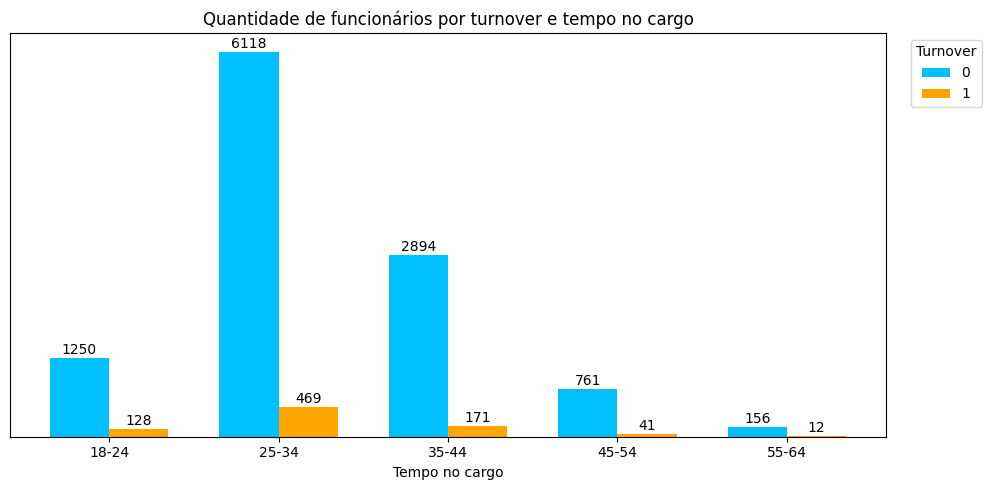

In [173]:
# Criar faixas de idade
faixas_idade = pd.cut(
    graph_idade,
    bins=[18, 25, 35, 45, 55, 65],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64']
)


# Tabela de frequências
tab_abs = pd.crosstab(faixas_idade, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['deepskyblue', 'orange']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e tempo no cargo')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Tempo no cargo')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

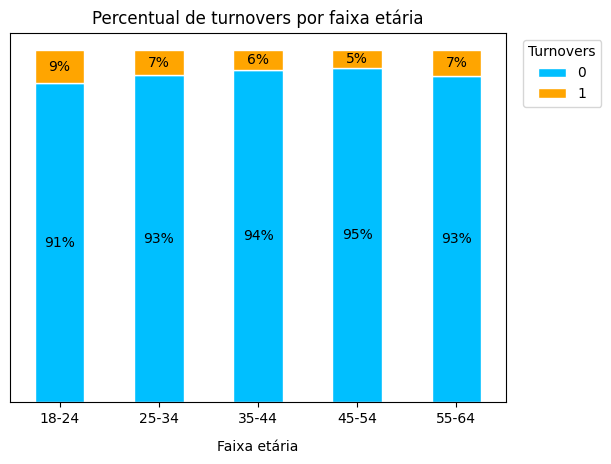

In [174]:
# Criar faixas etárias
faixas = pd.cut(
    graph_idade,
    bins=[18, 25, 35, 45, 55, 65],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64']
)

# Tabela de frequências e plotagem
ax = pd.crosstab(
        faixas,
        graph_turnover,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['deepskyblue', 'orange'],
        edgecolor='white',
        title='Percentual de turnovers por faixa etária'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal
plt.xlabel('Faixa etária', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

### *Análise demonstra que Faixa etária não possui correlação com o número de turnovers voluntários*

## Sexo x Turnover

In [175]:
var1 = dados['sexo']
var2 = dados['turnover_voluntario_90d']

pd.crosstab(
    var1,
    var2,
    normalize='index',
    margins=True
).round(3) * 100

turnover_voluntario_90d,0,1
sexo,,
F,93.0,7.0
M,93.2,6.8
All,93.2,6.8


In [176]:
print("\n--- PERFIL DAS SAÍDAS: SEXO (BASE 100) ---")

# 1. Filtramos a base para considerar APENAS os colaboradores que saíram
dados_sairam = dados[dados['turnover_voluntario_90d'] == 1]

# 2. Calculamos o percentual em cima desse novo grupo (a soma aqui dará 100%)
# O sort=False garante que ele vai respeitar a ordem (Junior -> Diretor) que definimos antes
distribuicao_saidas = dados_sairam['sexo'].value_counts(normalize=True, sort=False).round(3) * 100

# 3. Transformamos em uma tabela bem formatada
tabela_perfil_saidas = distribuicao_saidas.reset_index()
tabela_perfil_saidas.columns = ['Sexo', 'Representatividade nas Saídas (%)']

display(tabela_perfil_saidas)


--- PERFIL DAS SAÍDAS: SEXO (BASE 100) ---


,Sexo,Representatividade nas Saídas (%)
0,F,42.4
1,M,57.6


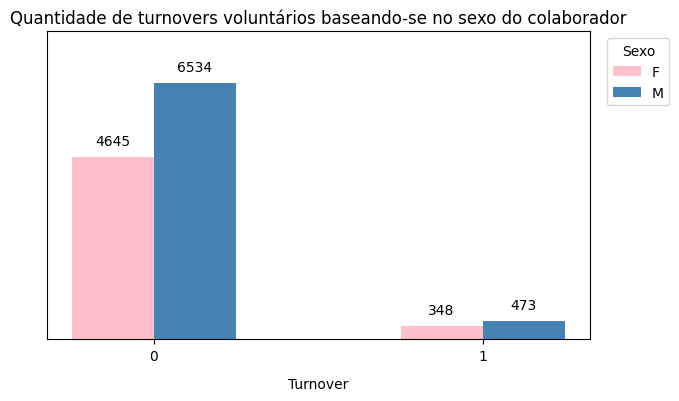

In [177]:
# Tabela de frequências
tab_abs = graph_sexo.groupby(graph_turnover, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.5 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(7, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['pink', 'steelblue', 'mediumseagreen', 'goldenrod']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de turnovers voluntários baseando-se no sexo do colaborador")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Turnover', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 300, str(v), ha='center')

plt.show()

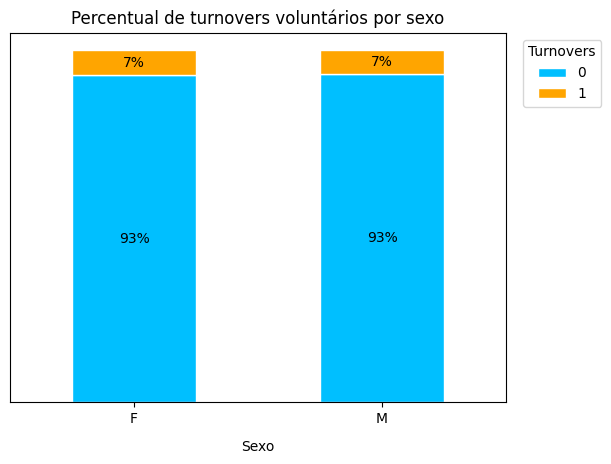

In [178]:
# Tabela de frequências e plotagem
ax = pd.crosstab(
        graph_sexo,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['deepskyblue', 'orange'],
        edgecolor='white',
        title='Percentual de turnovers voluntários por sexo'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Sexo', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

### *Análise demonstra que Sexo não possui correlação com o número de turnovers voluntários*

## Nível de Formação x Turnover

In [179]:
var1 = dados['nivel_formacao']
var2 = dados['turnover_voluntario_90d']

pd.crosstab(
    var1,
    var2,
    normalize='index',
    margins=True
).round(3) * 100

turnover_voluntario_90d,0,1
nivel_formacao,,
doutorado,93.3,6.7
mestrado,94.6,5.4
pos_graduacao,93.2,6.8
superior,92.6,7.4
All,93.2,6.8


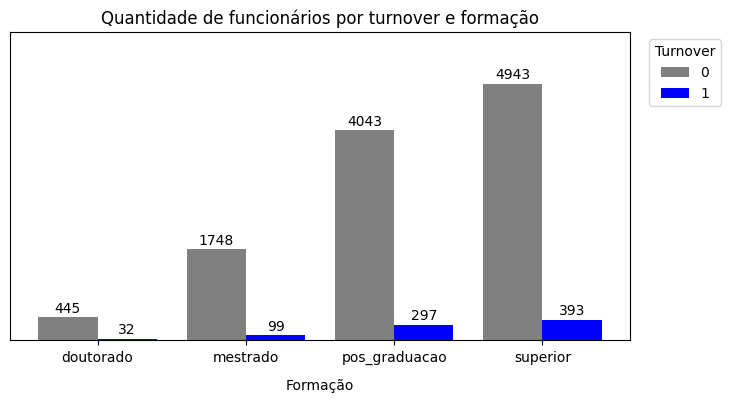

In [180]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_formacao, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['gray', 'blue', 'green', 'goldenrod']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e formação")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Formação', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

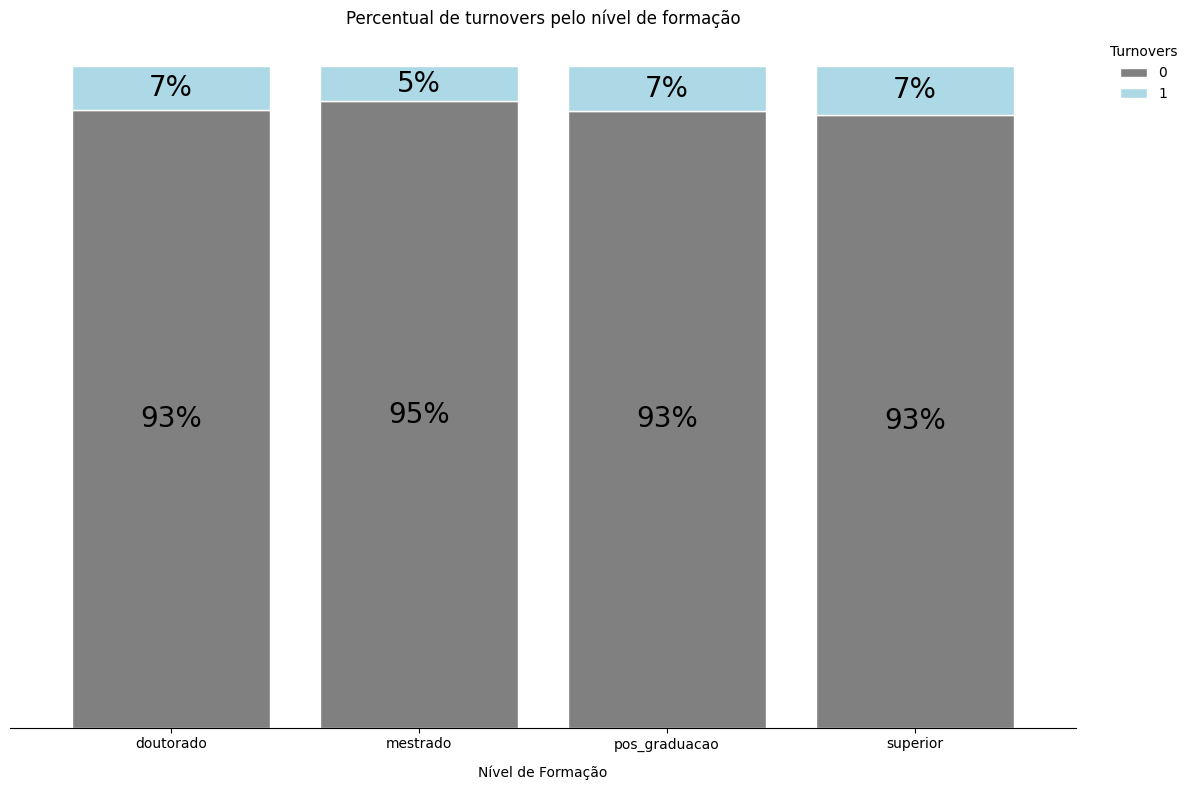

In [181]:
# Altere para os nomes das variáveis quantitativas desejadas
var1 = dados['turnover_voluntario_90d']
var2 = dados['nivel_formacao']

# Tabela de frequências e plotagem
ax = pd.crosstab(var2, var1, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['gray', 'lightblue','blue', 'gray'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pelo nível de formação',
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Nível de Formação', labelpad=10)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=20)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### *Análise demonstra que Nível de Formação não possui correlação com o número de turnovers voluntários*

## Area de Atuação x Turnover

In [182]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['turnover_voluntario_90d']
var2 = dados['area_atuacao']

In [183]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var1, var2, dropna=False, margins=True, margins_name='Total')

area_atuacao,dados,design,engenharia,negocios,operacoes,produto,Total
turnover_voluntario_90d,,,,,,,
0,1895,909,3921,1365,1055,2034,11179
1,117,64,265,114,120,141,821
Total,2012,973,4186,1479,1175,2175,12000


In [184]:
# Tabela de frequências relativas de dupla entrada, somando 1 no total geral
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total')

area_atuacao,dados,design,engenharia,negocios,operacoes,produto,Total
turnover_voluntario_90d,,,,,,,
0,0.157917,0.075750,0.326750,0.11375,0.087917,0.16950,0.931583
1,0.009750,0.005333,0.022083,0.00950,0.010000,0.01175,0.068417
Total,0.167667,0.081083,0.348833,0.12325,0.097917,0.18125,1.000000


In [185]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

area_atuacao,dados,design,engenharia,negocios,operacoes,produto,Total
turnover_voluntario_90d,,,,,,,
0,15.8,7.6,32.7,11.4,8.8,17.0,93.2
1,1.0,0.5,2.2,1.0,1.0,1.2,6.8
Total,16.8,8.1,34.9,12.3,9.8,18.1,100.0


In [186]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% nas linhas
pd.crosstab(var1, var2, dropna=False, normalize='index', margins=True, margins_name='Total').round(3) * 100

area_atuacao,dados,design,engenharia,negocios,operacoes,produto
turnover_voluntario_90d,,,,,,
0,17.0,8.1,35.1,12.2,9.4,18.2
1,14.3,7.8,32.3,13.9,14.6,17.2
Total,16.8,8.1,34.9,12.3,9.8,18.1


In [187]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% nas colunas
pd.crosstab(var1, var2, dropna=False, normalize='columns', margins=True, margins_name='Total').round(3) * 100

area_atuacao,dados,design,engenharia,negocios,operacoes,produto,Total
turnover_voluntario_90d,,,,,,,
0,94.2,93.4,93.7,92.3,89.8,93.5,93.2
1,5.8,6.6,6.3,7.7,10.2,6.5,6.8


*Comparação de medidas resumo*

In [188]:
# Altere para os nomes das variáveis desejadas, sendo uma quantitativa e uma qualitativa (ou quantitativa divididas em faixas)
var_quanti = dados['turnover_voluntario_90d']
var_quali = dados['area_atuacao']

In [189]:
# Medidas principais via "describe": média, desvio padrão, mínimo, quartis e máximo
pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
area_atuacao,,,,,,,,
dados,2012.0,0.058151,0.234087,0.0,0.0,0.0,0.0,1.0
design,973.0,0.065776,0.248018,0.0,0.0,0.0,0.0,1.0
engenharia,4186.0,0.063306,0.243542,0.0,0.0,0.0,0.0,1.0
negocios,1479.0,0.077079,0.266807,0.0,0.0,0.0,0.0,1.0
operacoes,1175.0,0.102128,0.302945,0.0,0.0,0.0,0.0,1.0
produto,2175.0,0.064828,0.246278,0.0,0.0,0.0,0.0,1.0


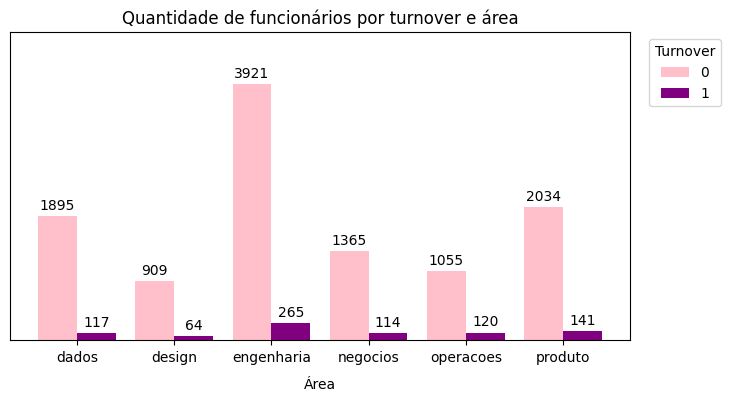

In [190]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_area_atuacao, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['pink', 'purple', 'green', 'goldenrod']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e área")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Área', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

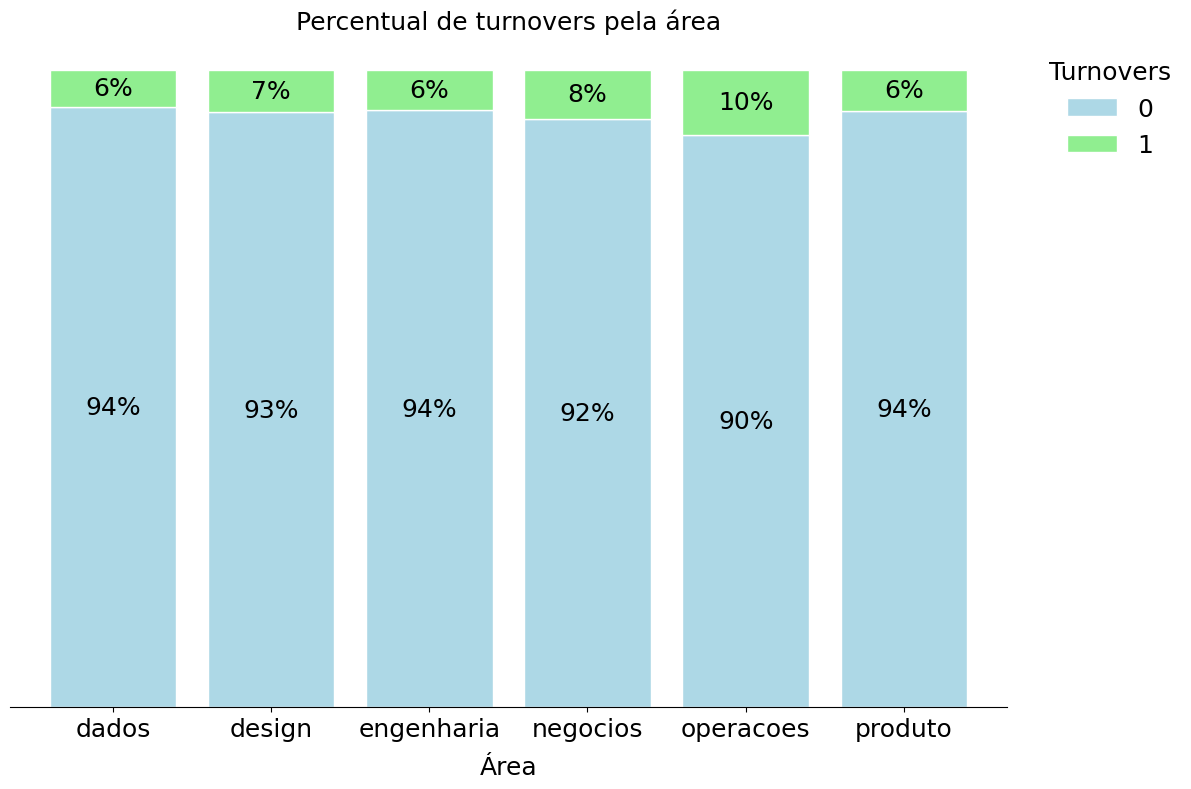

In [191]:
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_area_atuacao, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['lightblue', 'lightgreen'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pela área'
        )

# Tamanho do título
plt.title('Percentual de turnovers pela área', fontsize=18)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação e tamanho do texto do eixo horizontal
plt.xticks(rotation=0, fontsize=18)

# Título do eixo horizontal e espaçamento
plt.xlabel('Área', labelpad=10, fontsize=18)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=18)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1), fontsize=18,
    loc='upper left',
    frameon=False,
    title_fontsize=18
)

plt.tight_layout()
plt.show()


### *Análise demonstra que Área não possui correlação com o número de turnovers voluntários*

## Senioridade x Turnover

In [192]:
print("--- APLICANDO A ORDEM DA SENIORIDADE ---")
# Define a ordem exata desejada
ordem_senioridade = ['junior', 'pleno', 'senior', 'gerente', 'gerente sr./diretor']

# Transforma a coluna em uma categoria com a ordem forçada
dados['nivel_senioridade'] = pd.Categorical(
    dados['nivel_senioridade'],
    categories=ordem_senioridade,
    ordered=True
)

print("\n--- 1. FREQUÊNCIA ABSOLUTA: TURNOVER X SENIORIDADE (ORDENADA) ---")
# Tabela com a contagem exata e totais
tabela_abs = pd.crosstab(dados['nivel_senioridade'], dados['turnover_voluntario_90d'], margins=True)
display(tabela_abs)

print("\n--- 2. TAXA DE TURNOVER (%) POR SENIORIDADE ---")
# Tabela com o percentual de quem ficou e quem saiu por nível
tabela_perc = (pd.crosstab(dados['nivel_senioridade'], dados['turnover_voluntario_90d'], normalize='index') * 100).round(2)
display(tabela_perc)

--- APLICANDO A ORDEM DA SENIORIDADE ---

--- 1. FREQUÊNCIA ABSOLUTA: TURNOVER X SENIORIDADE (ORDENADA) ---


turnover_voluntario_90d,0,1,All
nivel_senioridade,,,
junior,2078,224,2302
pleno,3351,278,3629
senior,3491,203,3694
gerente,1463,79,1542
gerente sr./diretor,796,37,833
All,11179,821,12000



--- 2. TAXA DE TURNOVER (%) POR SENIORIDADE ---


turnover_voluntario_90d,0,1
nivel_senioridade,,
junior,90.27,9.73
pleno,92.34,7.66
senior,94.50,5.50
gerente,94.88,5.12
gerente sr./diretor,95.56,4.44


In [193]:
print("\n--- PERFIL DAS SAÍDAS: DISTRIBUIÇÃO DE SENIORIDADE (BASE 100) ---")

# Filtramos a base para considerar APENAS os colaboradores que saíram
dados_sairam = dados[dados['turnover_voluntario_90d'] == 1]

# Calculamos o percentual em cima desse novo grupo (a soma aqui dará 100%)
distribuicao_saidas = dados_sairam['nivel_senioridade'].value_counts(normalize=True, sort=False).round(3) * 100

# Transformamos em uma tabela bem formatada
tabela_perfil_saidas = distribuicao_saidas.reset_index()
tabela_perfil_saidas.columns = ['Nível de Senioridade', 'Representatividade nas Saídas (%)']

display(tabela_perfil_saidas)


--- PERFIL DAS SAÍDAS: DISTRIBUIÇÃO DE SENIORIDADE (BASE 100) ---


,Nível de Senioridade,Representatividade nas Saídas (%)
0,junior,27.3
1,pleno,33.9
2,senior,24.7
3,gerente,9.6
4,gerente sr./diretor,4.5


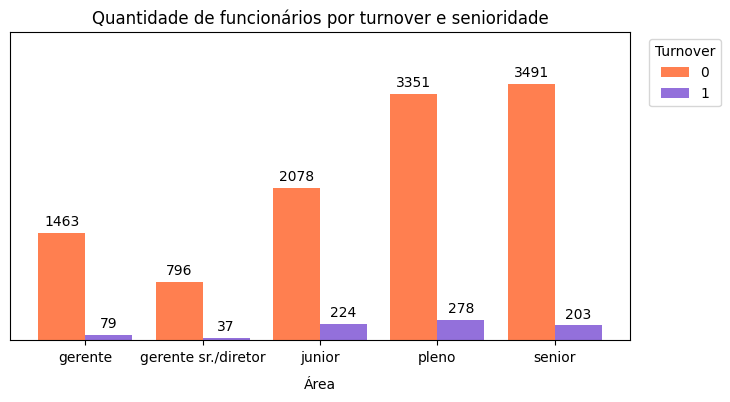

In [194]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_nivel_senioridade, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['coral', 'mediumpurple', 'green', 'goldenrod']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e senioridade")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Área', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

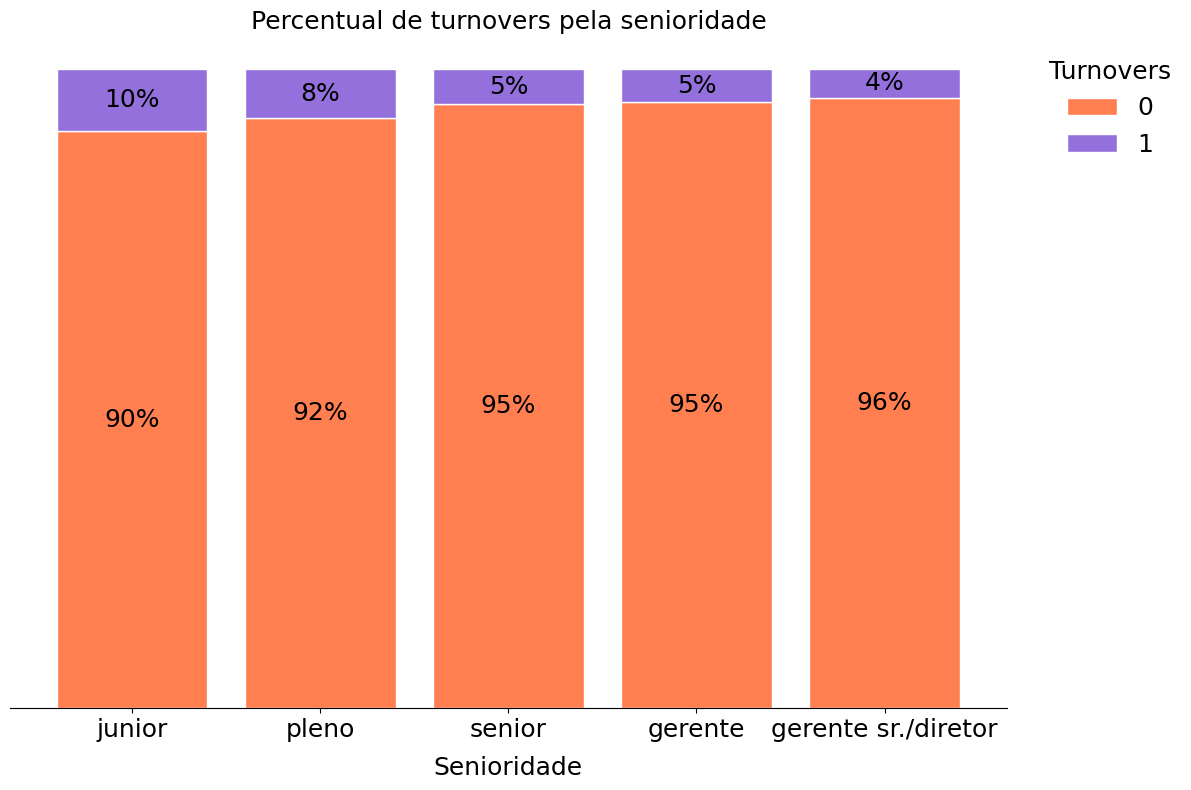

In [195]:
# Altere para os nomes das variáveis quantitativas desejadas
var_quali1 = dados['turnover_voluntario_90d']

# Define a ordem correta dos níveis de senioridade
ordem_senioridade = ['junior', 'pleno', 'senior', 'gerente', 'gerente sr./diretor']


graph_senioridade = pd.Categorical(
    dados['nivel_senioridade'],
    categories=ordem_senioridade,
    ordered=True
)
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_senioridade, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['coral', 'mediumpurple'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pela senioridade'
        )

# Tamanho do título
plt.title('Percentual de turnovers pela senioridade', fontsize=18)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação e tamanho do texto do eixo horizontal
plt.xticks(rotation=0, fontsize=18)

# Título do eixo horizontal e espaçamento
plt.xlabel('Senioridade', labelpad=10, fontsize=18)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=18)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1), fontsize=18,
    loc='upper left',
    frameon=False,
    title_fontsize=18
)

plt.tight_layout()
plt.show()


### *Análise demonstra que Nível de Senioridade não possui correlação com o número de turnovers voluntários*

## Regime de Trabalho x Turnover

In [196]:
print("\n--- 1. FREQUÊNCIA ABSOLUTA: TURNOVER X REGIME DE TRABALHO ---")
# Tabela com a contagem exata e totais
tabela_abs = pd.crosstab(dados['regime_trabalho'], dados['turnover_voluntario_90d'], margins=True)
display(tabela_abs)

print("\n--- 2. TAXA DE TURNOVER (%) POR REGIME DE TRABALHO ---")
# Tabela com o percentual de quem ficou e quem saiu por nível
tabela_perc = (pd.crosstab(dados['regime_trabalho'], dados['turnover_voluntario_90d'], normalize='index') * 100).round(2)
display(tabela_perc)


--- 1. FREQUÊNCIA ABSOLUTA: TURNOVER X REGIME DE TRABALHO ---


turnover_voluntario_90d,0,1,All
regime_trabalho,,,
hibrido,4511,322,4833
presencial,2264,322,2586
remoto,4404,177,4581
All,11179,821,12000



--- 2. TAXA DE TURNOVER (%) POR REGIME DE TRABALHO ---


turnover_voluntario_90d,0,1
regime_trabalho,,
hibrido,93.34,6.66
presencial,87.55,12.45
remoto,96.14,3.86


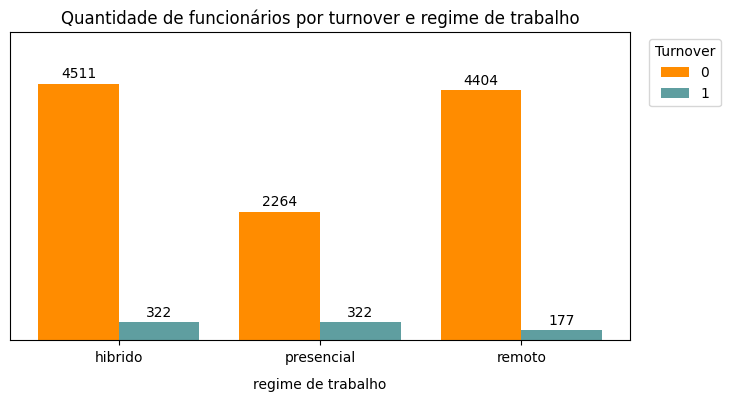

In [197]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_regime_trabalho, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['darkorange', 'cadetblue']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e regime de trabalho")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('regime de trabalho', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

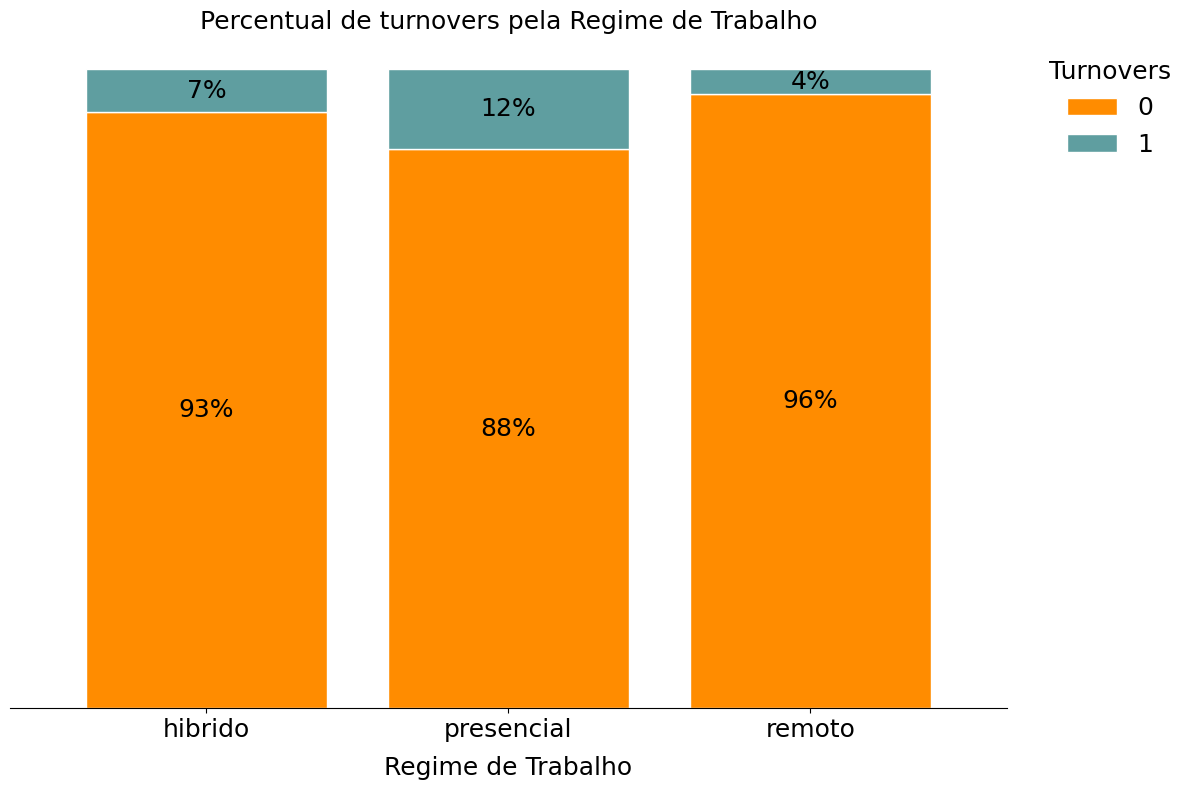

In [198]:
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_regime_trabalho, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['darkorange', 'cadetblue'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pela Regime de Trabalho'
        )

# Tamanho do título
plt.title('Percentual de turnovers pela Regime de Trabalho', fontsize=18)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação e tamanho do texto do eixo horizontal
plt.xticks(rotation=0, fontsize=18)

# Título do eixo horizontal e espaçamento
plt.xlabel('Regime de Trabalho', labelpad=10, fontsize=18)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=18)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1), fontsize=18,
    loc='upper left',
    frameon=False,
    title_fontsize=18
)

plt.tight_layout()
plt.show()

### *A análise demonstra que o Regime de Trabalho está diretamente associado ao turnover voluntário. Isso ocorre pois existe uma relação proporcional: quanto mais tempo os funcionários trabalham em regime presencial por semana, maior é a taxa de turnover voluntário*

## Tempo no Cargo x Turnover

In [199]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['turnover_voluntario_90d']
var2 = dados['tempo_no_cargo_meses']
pontos_corte = [var2.min(), 6, 12, 24, 48, var2.max()]
var_quanti_faixas = pd.cut(var2, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
pd.crosstab(var_quanti_faixas, var1, dropna=False, margins=True, margins_name='Total')
pd.crosstab(var_quanti_faixas, var1, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
tempo_no_cargo_meses,,,
"(0.999, 6.0]",18.0,1.3,19.2
"(6.0, 12.0]",17.2,1.4,18.6
"(12.0, 24.0]",26.9,1.9,28.7
"(24.0, 48.0]",24.7,2.0,26.7
"(48.0, 119.0]",6.4,0.3,6.8
Total,93.2,6.8,100.0


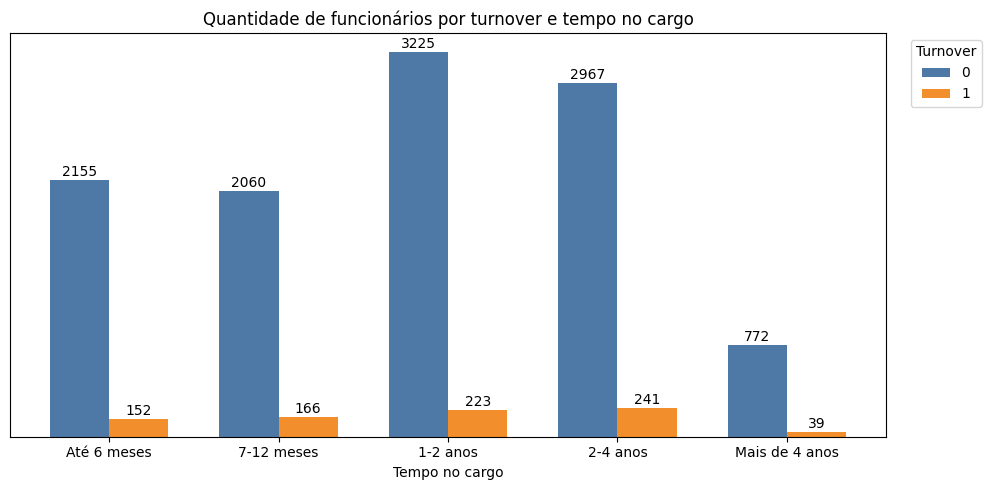

In [200]:
# Criar faixas de tempo no cargo
faixas_tempo = pd.cut(
    graph_tempo_no_cargo_meses,
    bins=[0, 6, 12, 24, 48, 119],
    labels=[
        'Até 6 meses',
        '7-12 meses',
        '1-2 anos',
        '2-4 anos',
        'Mais de 4 anos'
    ]
)

# Tabela de frequências
tab_abs = pd.crosstab(faixas_tempo, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['#4E79A7', '#F28E2B']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e tempo no cargo')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Tempo no cargo')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

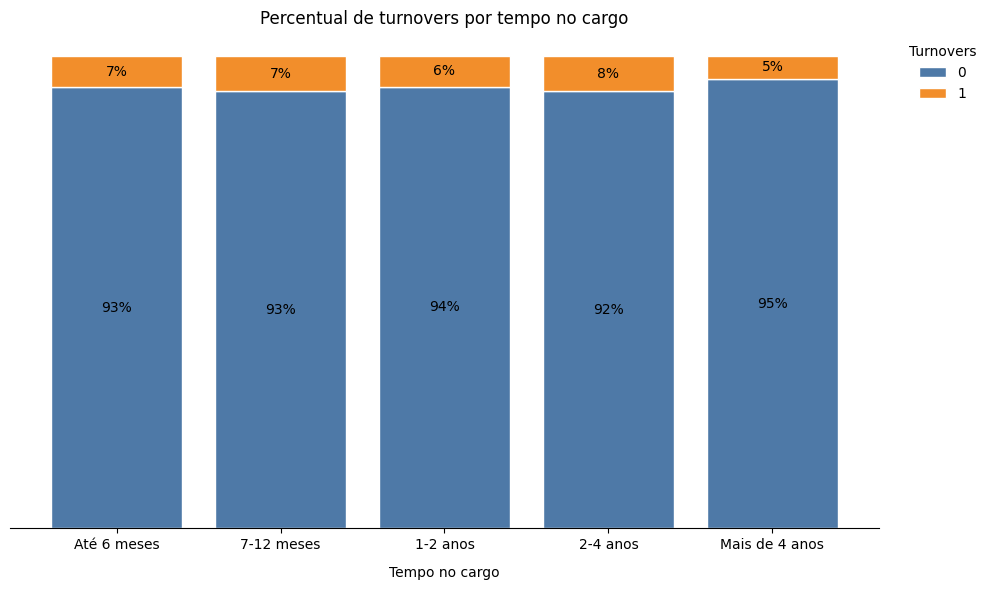

In [201]:
# Criar faixas de tempo no cargo
faixas_tempo = pd.cut(
    graph_tempo_no_cargo_meses,
    bins=[0, 6, 12, 24, 48, 119],
    labels=[
        'Até 6 meses',
        '7-12 meses',
        '1-2 anos',
        '2-4 anos',
        'Mais de 4 anos'
    ]
)

# Tabela de frequências e plotagem
ax = pd.crosstab(
        faixas_tempo,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color = ['#4E79A7', '#F28E2B'],
        edgecolor='white',
        width=0.8,
        figsize=(10,6),
        title='Percentual de turnovers por tempo no cargo'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal
plt.xlabel('Tempo no cargo', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=10)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### *A análise demonstra que o Tempo no Cargo não possui correlação com o número de turnovers voluntários*

## Promoção Recente x Turnover

In [202]:
var1 = dados['turnover_voluntario_90d']
var2 = dados['promocao_12m']
pd.crosstab(var1, var2, dropna=False, margins=True, margins_name='Total')
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total')
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100
pd.crosstab(var1, var2, dropna=False, normalize='index', margins=True, margins_name='Total').round(3) * 100
pd.crosstab(var1, var2, dropna=False, normalize='columns', margins=True, margins_name='Total').round(3) * 100

promocao_12m,nao,sim,Total
turnover_voluntario_90d,,,
0,92.2,95.4,93.2
1,7.8,4.6,6.8


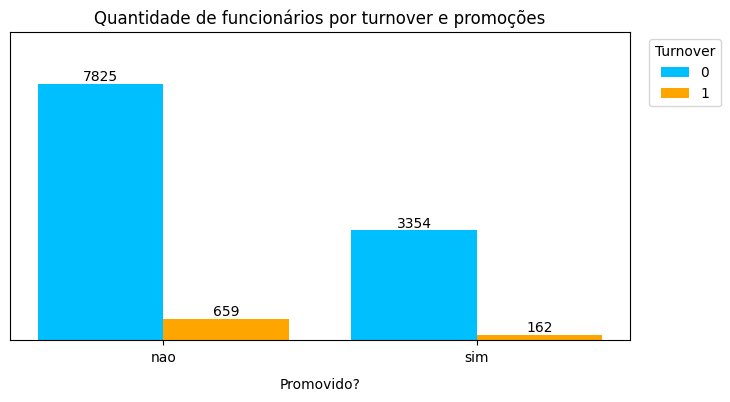

In [203]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_promocao, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(8, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['deepskyblue', 'orange']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e promoções")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Promovido?', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

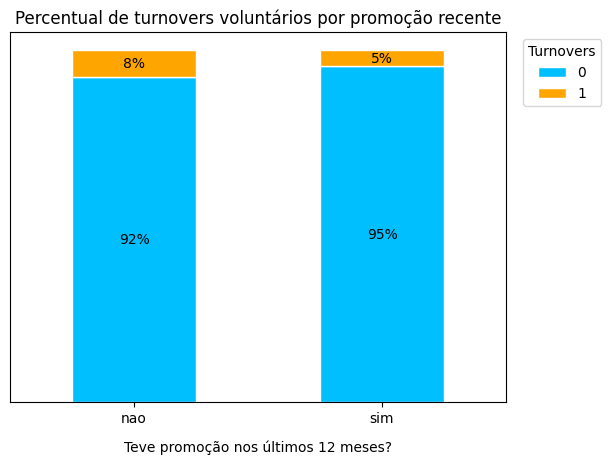

In [204]:
# Tabela de frequências e plotagem
ax = pd.crosstab(
        graph_promocao,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['deepskyblue', 'orange'],
        edgecolor='white',
        title='Percentual de turnovers voluntários por promoção recente'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Teve promoção nos últimos 12 meses?', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

### *Análise demonstra que ter sido promovido ou não nos últimos 12 meses não é necessariamente um motivo para o número de turnovers voluntários, porém a maior quantidade de funcionarios que tiveram turnover voluntário foram os que não foram promovidos nos últimos 12 meses*

## Salário Mensal x Turnover

In [205]:
var1 = dados['turnover_voluntario_90d']
var2 = dados['salario_mensal']
pontos_corte = [var2.min(), 10000, 15000, 23000, var2.max()]
var_quanti_faixas = pd.cut(var2, bins=pontos_corte, include_lowest=True)
pd.crosstab(var_quanti_faixas, var1, dropna=False, margins=True, margins_name='Total')

turnover_voluntario_90d,0,1,Total
salario_mensal,,,
"(2999.999, 10000.0]",3083,361,3444
"(10000.0, 15000.0]",2528,178,2706
"(15000.0, 23000.0]",2824,154,2978
"(23000.0, 67300.0]",2744,128,2872
Total,11179,821,12000


In [206]:
pd.crosstab(var_quanti_faixas, var1, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
salario_mensal,,,
"(2999.999, 10000.0]",25.7,3.0,28.7
"(10000.0, 15000.0]",21.1,1.5,22.6
"(15000.0, 23000.0]",23.5,1.3,24.8
"(23000.0, 67300.0]",22.9,1.1,23.9
Total,93.2,6.8,100.0


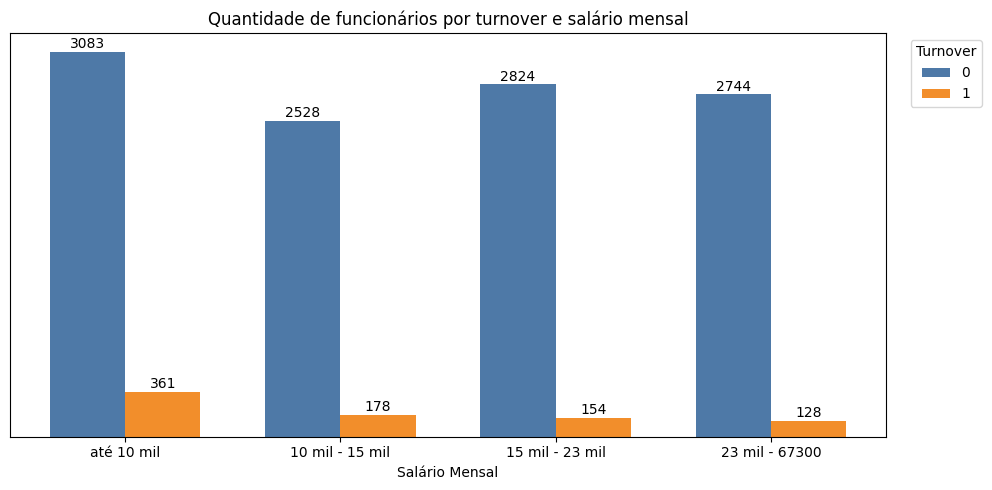

In [207]:
# Criar faixas de salario
faixas_salario = pd.cut(
    graph_salario,
    bins=[2999, 10000, 15000, 23000, 67300],
    labels=[
        'até 10 mil',
        '10 mil - 15 mil',
        '15 mil - 23 mil',
        '23 mil - 67300'
    ]
)

# Tabela de frequências
tab_abs = pd.crosstab(faixas_salario, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['#4E79A7', '#F28E2B']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e salário mensal')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Salário Mensal')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

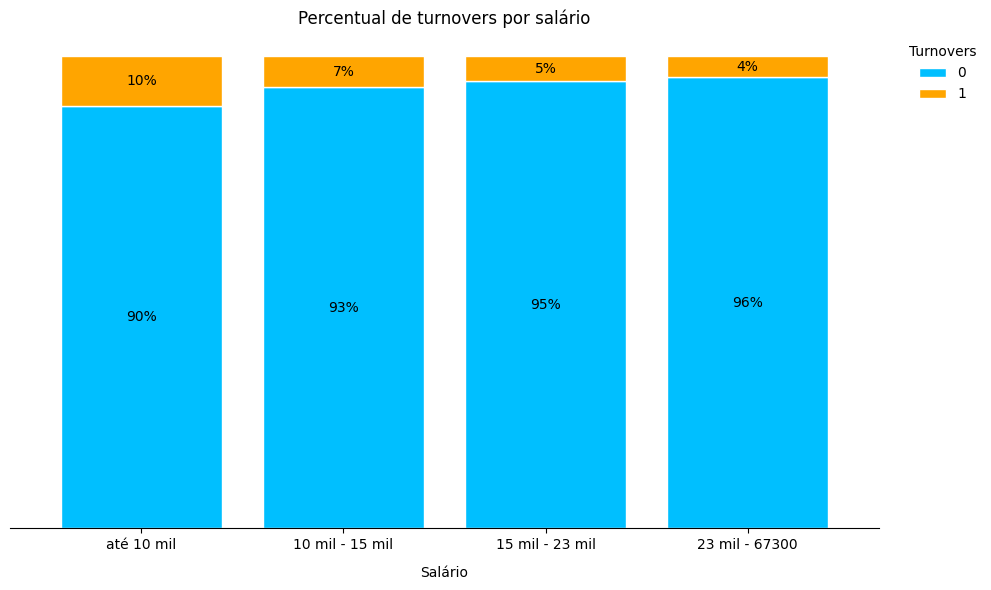

In [208]:
# Criar faixas de tempo no cargo
faixas_salario = pd.cut(
    graph_salario,
    bins=[2999, 10000, 15000, 23000, 67300],
    labels=[
        'até 10 mil',
        '10 mil - 15 mil',
        '15 mil - 23 mil',
        '23 mil - 67300'
    ]
)

# Tabela de frequências e plotagem
ax = pd.crosstab(
        faixas_salario,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['deepskyblue', 'orange'],
        edgecolor='white',
        width=0.8,
        figsize=(10,6),
        title='Percentual de turnovers por salário'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal
plt.xlabel('Salário', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=10)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### *A análise demonstra que o salário mensal possui uma relação com o turnover voluntário. Porém essas análise carecem de profundidade (ignoram senioridade, por exemplo), por conta disso análises trivariadas serão feitas futuramente*

In [209]:
pd.crosstab(var_quanti_faixas, var1, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
salario_mensal,,,
"(2999.999, 10000.0]",25.7,3.0,28.7
"(10000.0, 15000.0]",21.1,1.5,22.6
"(15000.0, 23000.0]",23.5,1.3,24.8
"(23000.0, 67300.0]",22.9,1.1,23.9
Total,93.2,6.8,100.0


## Percentual de Bonus x Turnover

In [210]:
var1 = dados['turnover_voluntario_90d']
var2 = dados['perc_bonus_ultimo_ciclo']
pd.crosstab(var1, var2, dropna=False, margins=True, margins_name='Total')

perc_bonus_ultimo_ciclo,0.0,100.0,200.0,Total
turnover_voluntario_90d,,,,
0,3777,5085,2317,11179
1,413,324,84,821
Total,4190,5409,2401,12000


In [211]:
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

perc_bonus_ultimo_ciclo,0.0,100.0,200.0,Total
turnover_voluntario_90d,,,,
0,31.5,42.4,19.3,93.2
1,3.4,2.7,0.7,6.8
Total,34.9,45.1,20.0,100.0


In [212]:
pd.crosstab(var1, var2, dropna=False, normalize='columns', margins=True, margins_name='Total').round(3) * 100

perc_bonus_ultimo_ciclo,0.0,100.0,200.0,Total
turnover_voluntario_90d,,,,
0,90.1,94.0,96.5,93.2
1,9.9,6.0,3.5,6.8


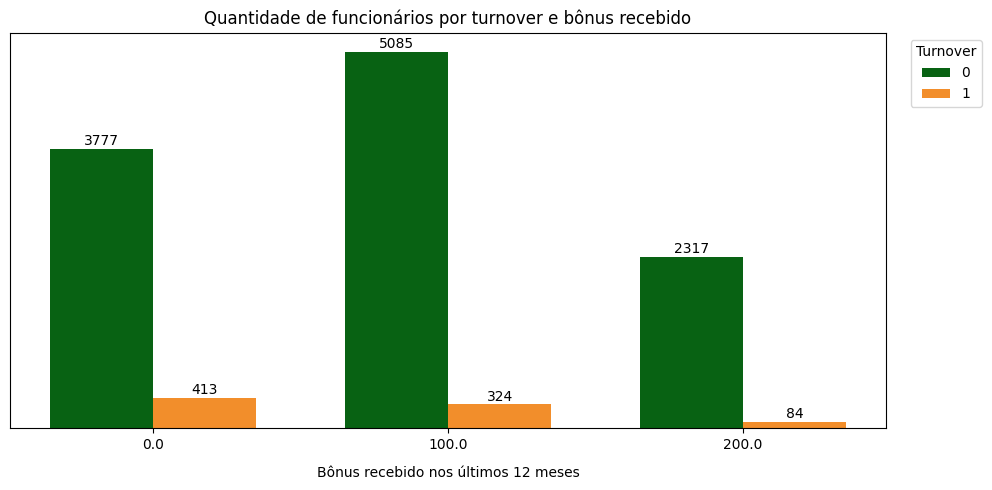

In [213]:
# Tabela de frequências
tab_abs = pd.crosstab(graph_bonus, graph_turnover)

turnovers = tab_abs.columns
bonus = tab_abs.index

x = np.arange(len(bonus))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['#086213', '#F28E2B']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e bônus recebido')

# Eixo X
plt.xticks(
    x + largura / 2,
    bonus,
    rotation=0
)

plt.xlabel('Bônus recebido nos últimos 12 meses', labelpad=10)

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

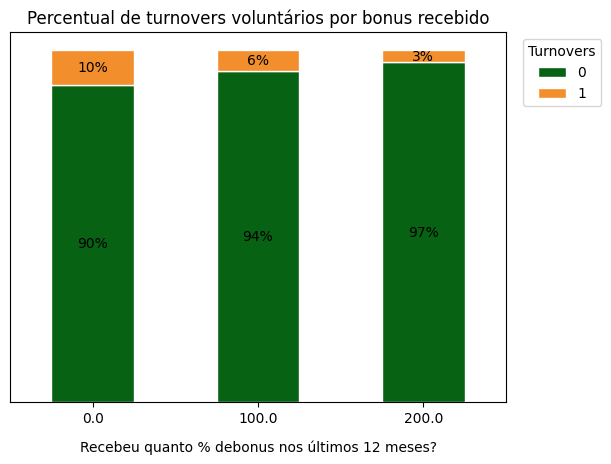

In [214]:
# Tabela de frequências e plotagem
ax = pd.crosstab(
        graph_bonus,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['#086213', '#F28E2B'],
        edgecolor='white',
        title='Percentual de turnovers voluntários por bonus recebido'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Recebeu quanto % debonus nos últimos 12 meses?', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

### *A análise demonstra que o bônus recebido nos últimos 12 meses está diretamente associado ao turnover voluntário. Isso ocorre pois existe uma relação inversamente proporcional: quanto menor o percentual do bônus recebido, maior é a taxa de turnover voluntário*

## Nota de Avaliação x Turnover

In [215]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['nota_avaliacao_desempenho']
var2 = dados['turnover_voluntario_90d']

In [216]:
# Altere para os pontos de corte desejados (o mínimo e o máximo devem estar abrangidos na lista)
pontos_corte = [var1.min(), 3, 4, var1.max()]

In [217]:
# Criação de vetor representando a variável dividida em faixas
var_quanti_faixas = pd.cut(var1, bins=pontos_corte, include_lowest=True)

In [218]:
# Tabela de frequências absolutas
var_quanti_faixas.value_counts(dropna=False, sort=False)

,count
nota_avaliacao_desempenho,
"(0.999, 3.0]",4091
"(3.0, 4.0]",5657
"(4.0, 5.0]",2252


In [219]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var_quanti_faixas, var2, dropna=False, margins=True, margins_name='Total')

turnover_voluntario_90d,0,1,Total
nota_avaliacao_desempenho,,,
"(0.999, 3.0]",3751,340,4091
"(3.0, 4.0]",5349,308,5657
"(4.0, 5.0]",2079,173,2252
Total,11179,821,12000


In [220]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var_quanti_faixas, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
nota_avaliacao_desempenho,,,
"(0.999, 3.0]",31.3,2.8,34.1
"(3.0, 4.0]",44.6,2.6,47.1
"(4.0, 5.0]",17.3,1.4,18.8
Total,93.2,6.8,100.0


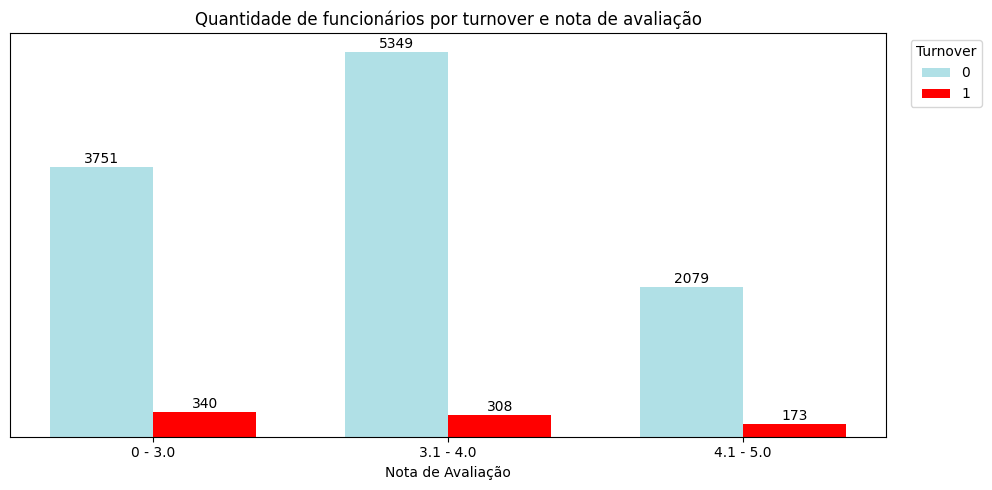

In [221]:
# Criar faixas de salario
faixas_notas = pd.cut(
    graph_nota_avaliacao_desempenho,
    bins=[0, 3, 4, 5],
    labels=[
        '0 - 3.0',
        '3.1 - 4.0',
        '4.1 - 5.0'
    ]
)

# Tabela de frequências
tab_abs = pd.crosstab(faixas_notas, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['powderblue', 'red']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e nota de avaliação')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Nota de Avaliação')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

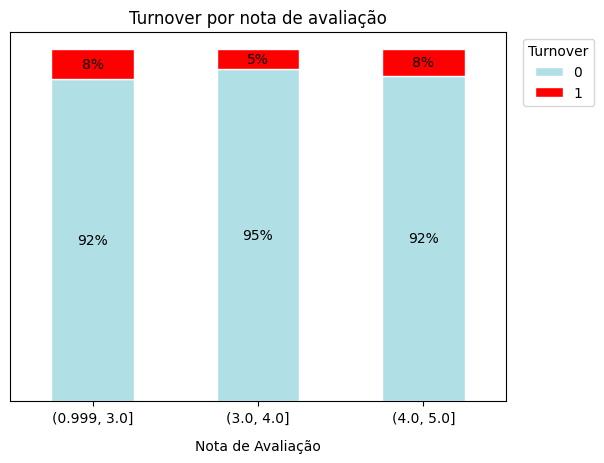

In [222]:
# Tabela de frequências e plotagem
ax = pd.crosstab(var_quanti_faixas, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['powderblue', 'red', 'dodgerblue'],
        edgecolor='white',
        title='Turnover por nota de avaliação',

        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Nota de Avaliação', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [f'{v.get_height() * 100:.0f}%' for v in bar]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### *A análise demonstra que a Nota de Avaliação não possui correlação com o número de turnovers voluntários*

## Nota ENPS x Turnover

In [223]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['turnover_voluntario_90d']
var2 = dados['nota_enps']

In [224]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var1, var2, dropna=False, margins=True, margins_name='Total')

nota_enps,0,1,2,3,4,5,6,7,8,9,10,Total
turnover_voluntario_90d,,,,,,,,,,,,
0,49,91,275,592,1102,1680,2160,2179,1681,908,462,11179
1,10,32,67,85,152,179,124,85,48,24,15,821
Total,59,123,342,677,1254,1859,2284,2264,1729,932,477,12000


In [225]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

nota_enps,0,1,2,3,4,5,6,7,8,9,10,Total
turnover_voluntario_90d,,,,,,,,,,,,
0,0.4,0.8,2.3,4.9,9.2,14.0,18.0,18.2,14.0,7.6,3.8,93.2
1,0.1,0.3,0.6,0.7,1.3,1.5,1.0,0.7,0.4,0.2,0.1,6.8
Total,0.5,1.0,2.8,5.6,10.4,15.5,19.0,18.9,14.4,7.8,4.0,100.0


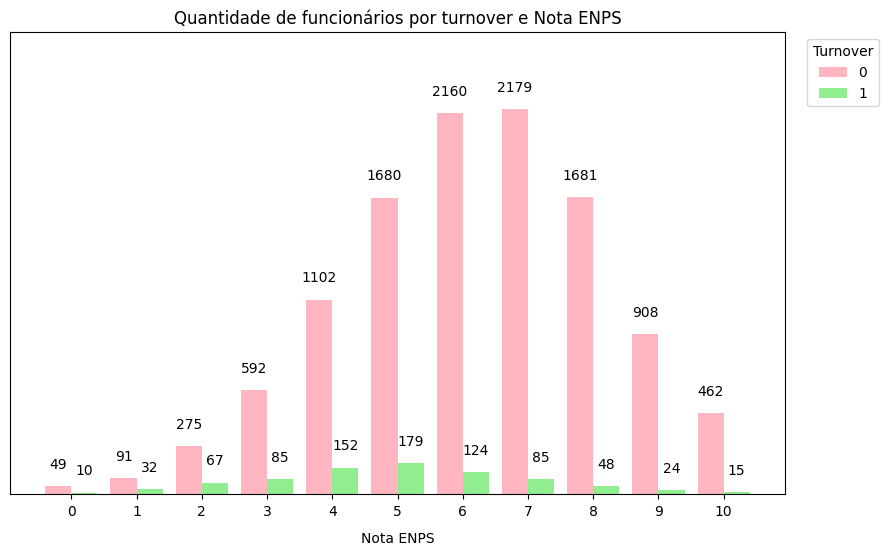

In [226]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_nota_enps, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(10, 6))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['lightpink', 'lightgreen']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e Nota ENPS")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Nota ENPS', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

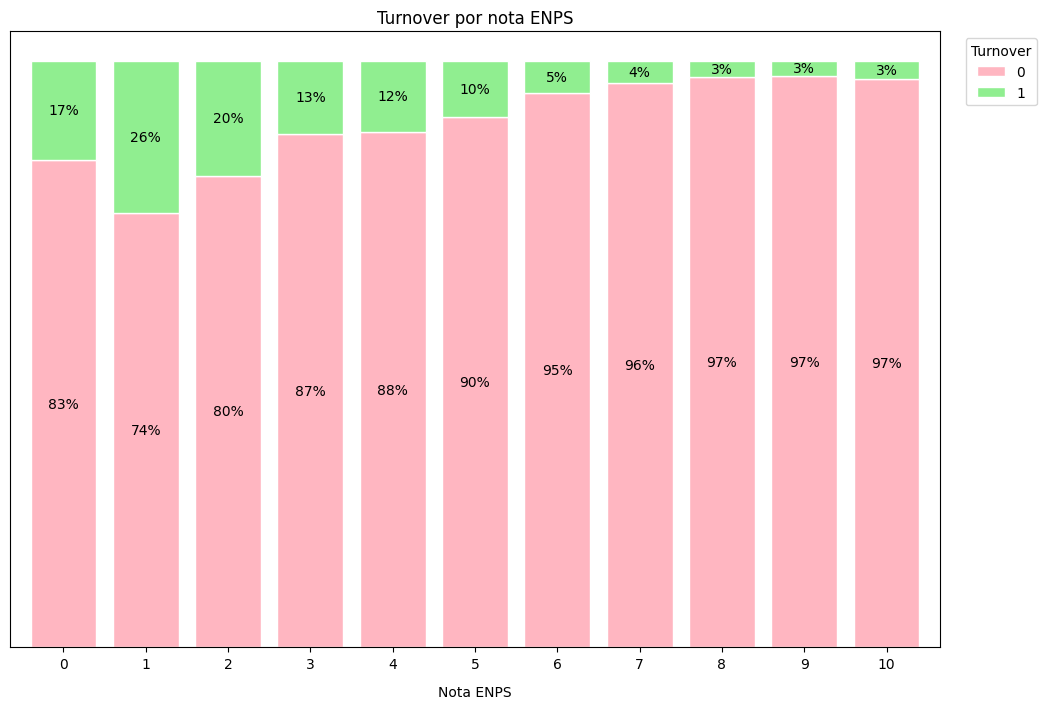

In [227]:
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_nota_enps, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['lightpink', 'lightgreen'],
        edgecolor='white',
        title='Turnover por nota ENPS',
        width=0.8,
        figsize=(12,8),
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Nota ENPS', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [f'{v.get_height() * 100:.0f}%' for v in bar]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### *A análise demonstra que a nota ENPS recebida está associado ao turnover voluntário. Isso ocorre pois funcionários com menores notas ENPS possuem uma maior taxa de turnover voluntário*

## Feedbacks Recebidos x Turnover

In [228]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['qtd_feedbacks_recebidos_6m']
var2 = dados['turnover_voluntario_90d']

In [229]:
# Altere para os pontos de corte desejados (o mínimo e o máximo devem estar abrangidos na lista)
pontos_corte = [var1.min(), 3, 7, var1.max()]

In [230]:
# Criação de vetor representando a variável dividida em faixas
var_quanti_faixas = pd.cut(var1, bins=pontos_corte, include_lowest=True)

In [231]:
# Tabela de frequências absolutas
var_quanti_faixas.value_counts(dropna=False, sort=False)

,count
qtd_feedbacks_recebidos_6m,
"(-0.001, 3.0]",6080
"(3.0, 7.0]",4865
"(7.0, 16.0]",1055


In [232]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var_quanti_faixas, var2, dropna=False, margins=True, margins_name='Total')

turnover_voluntario_90d,0,1,Total
qtd_feedbacks_recebidos_6m,,,
"(-0.001, 3.0]",5584,496,6080
"(3.0, 7.0]",4589,276,4865
"(7.0, 16.0]",1006,49,1055
Total,11179,821,12000


In [233]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var_quanti_faixas, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
qtd_feedbacks_recebidos_6m,,,
"(-0.001, 3.0]",46.5,4.1,50.7
"(3.0, 7.0]",38.2,2.3,40.5
"(7.0, 16.0]",8.4,0.4,8.8
Total,93.2,6.8,100.0


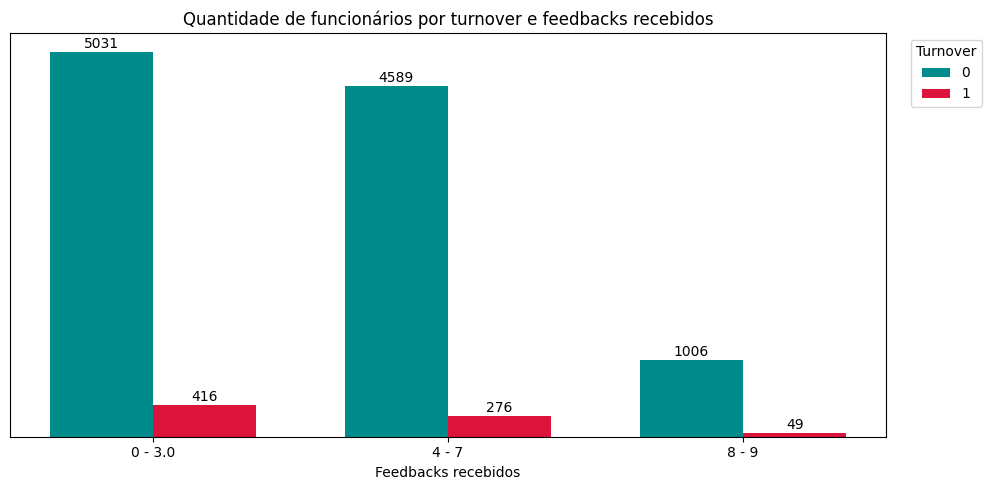

In [234]:
# Criar faixas de feedback
faixas_feedback = pd.cut(
    graph_qtd_feedbacks_recebidos,
    bins=[0, 3, 7, 16],
    labels=[
        '0 - 3.0',
        '4 - 7',
        '8 - 9'
    ]
)

# Tabela de frequências
tab_abs = pd.crosstab(faixas_feedback, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['darkcyan', 'crimson']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e feedbacks recebidos')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Feedbacks recebidos')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

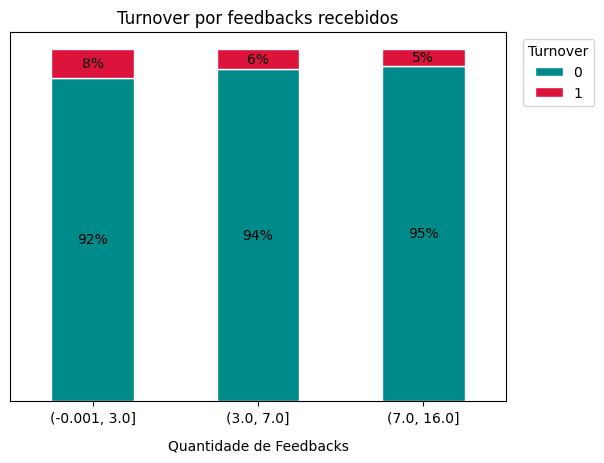

In [235]:
# Tabela de frequências e plotagem
ax = pd.crosstab(var_quanti_faixas, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['darkcyan', 'crimson'],
        edgecolor='white',
        title='Turnover por feedbacks recebidos',
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Quantidade de Feedbacks', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [f'{v.get_height() * 100:.0f}%' for v in bar]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### *A análise demonstra que a quantidade de feedbacks recebidos nos últimos 12 meses está diretamente associado ao turnover voluntário. Isso ocorre pois existe uma relação inversamente proporcional: quanto a quantidade de feedback recebido, maior é a taxa de turnover voluntário*

## Dias Abscentes x Turnover

In [236]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['absenteismo_dias_6m']
var2 = dados['turnover_voluntario_90d']

In [237]:
# Altere para os pontos de corte desejados (o mínimo e o máximo devem estar abrangidos na lista)
pontos_corte = [var1.min(), 2, 4, var1.max()]

In [238]:
# Criação de vetor representando a variável dividida em faixas
var_quanti_faixas = pd.cut(var1, bins=pontos_corte, include_lowest=True)

In [239]:
# Tabela de frequências absolutas
var_quanti_faixas.value_counts(dropna=False, sort=False)

,count
absenteismo_dias_6m,
"(-0.001, 2.0]",10339
"(2.0, 4.0]",986
"(4.0, 15.0]",675


In [240]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var_quanti_faixas, var2, dropna=False, margins=True, margins_name='Total')

turnover_voluntario_90d,0,1,Total
absenteismo_dias_6m,,,
"(-0.001, 2.0]",9710,629,10339
"(2.0, 4.0]",896,90,986
"(4.0, 15.0]",573,102,675
Total,11179,821,12000


In [241]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var_quanti_faixas, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
absenteismo_dias_6m,,,
"(-0.001, 2.0]",80.9,5.2,86.2
"(2.0, 4.0]",7.5,0.8,8.2
"(4.0, 15.0]",4.8,0.8,5.6
Total,93.2,6.8,100.0


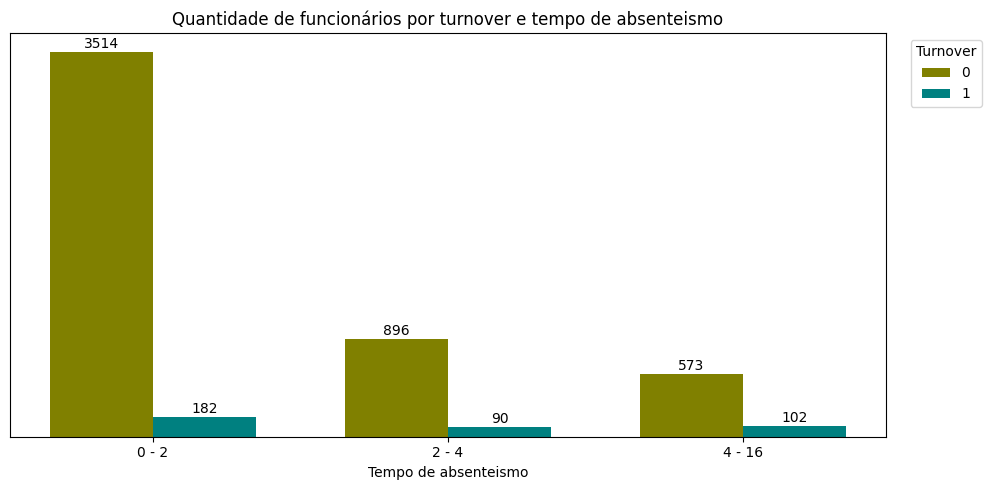

In [242]:
# Criar faixas de absenteismo
faixas_abs = pd.cut(
    graph_absenteismo_dias,
    bins=[0, 2, 4, 15],
    labels=[
        '0 - 2',
        '2 - 4',
        '4 - 16'
    ]
)

# Tabela de frequências
tab_abs = pd.crosstab(faixas_abs, graph_turnover)

categorias = tab_abs.index
turnovers = tab_abs.columns

x = np.arange(len(categorias))
largura = 0.35

# Figura
plt.figure(figsize=(10, 5))

cores = ['olive', 'teal']

# Barras agrupadas
for i, turnover in enumerate(turnovers):
    valores = tab_abs[turnover]

    plt.bar(
        x + i * largura,
        valores,
        largura,
        label=turnover,
        color=cores[i]
    )

# Título
plt.title('Quantidade de funcionários por turnover e tempo de absenteismo')

# Eixo X
plt.xticks(
    x + largura / 2,
    categorias,
    rotation=0
)

plt.xlabel('Tempo de absenteismo')

# Ocultar eixo Y
plt.gca().get_yaxis().set_visible(False)

# Legenda
plt.legend(
    title='Turnover',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Rótulos sobre as barras
for i, turnover in enumerate(turnovers):
    for j, valor in enumerate(tab_abs[turnover]):
        plt.text(
            j + i * largura,
            valor + tab_abs.values.max() * 0.01,
            str(valor),
            ha='center'
        )

plt.tight_layout()
plt.show()

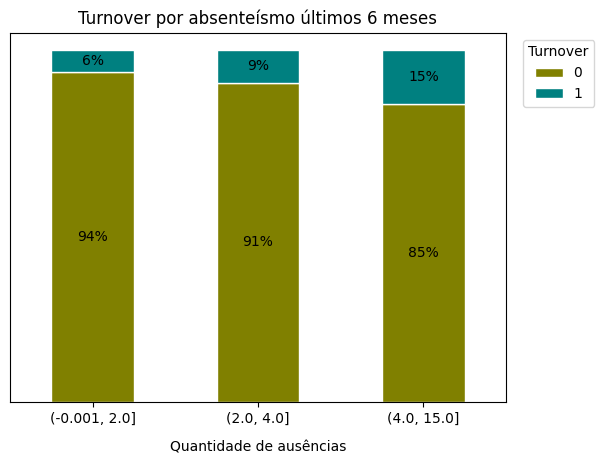

In [243]:
# Tabela de frequências e plotagem
ax = pd.crosstab(var_quanti_faixas, var2, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['olive', 'teal'],
        edgecolor='white',
        title='Turnover por absenteísmo últimos 6 meses',
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Quantidade de ausências', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [f'{v.get_height() * 100:.0f}%' for v in bar]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### *A análise demonstra que a quantidade de ausências nos últimos 6 meses não está diretamente associado ao turnover voluntário. Porém uma grande taxa dos funcionários que se ausentam por uma grande quantidade de dias acabam solicitando o turnover*

## Mudou de Gestor x Turnover

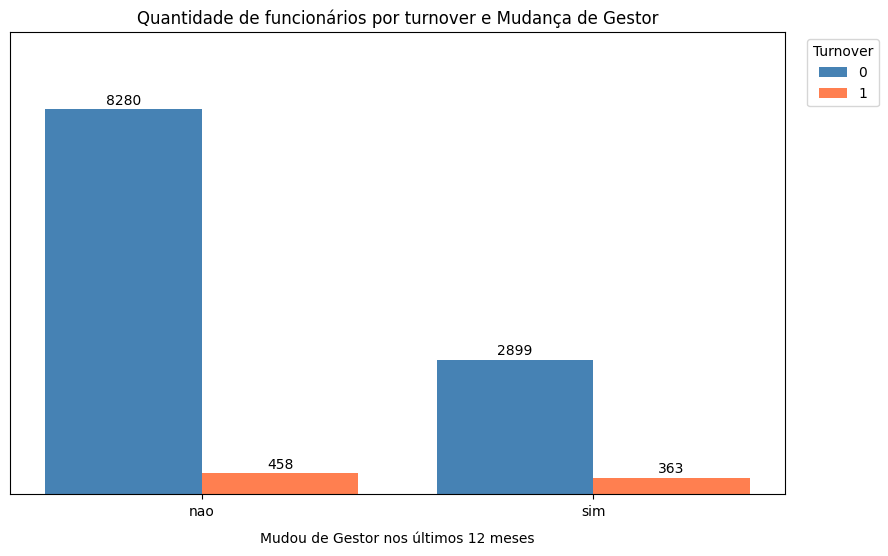

In [244]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_mudou_de_gestor, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(10, 6))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['steelblue', 'coral']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e Mudança de Gestor")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Mudou de Gestor nos últimos 12 meses', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

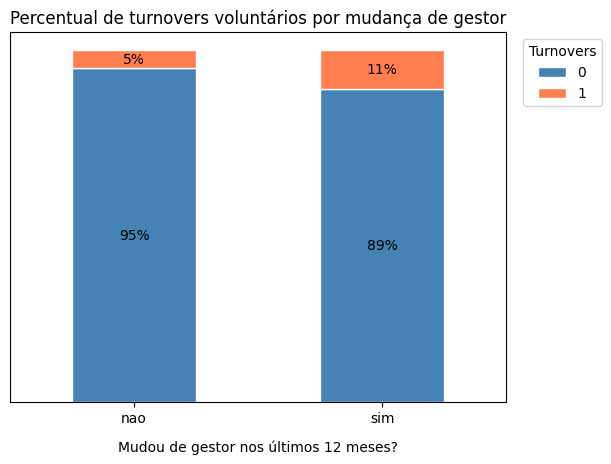

In [245]:
# Tabela de frequências e plotagem
ax = pd.crosstab(
        graph_mudou_de_gestor,
        graph_turnover,
        dropna=True,
        normalize='index'
    ).plot(
        kind='bar',
        stacked=True,
        color=['steelblue', 'coral'],
        edgecolor='white',
        title='Percentual de turnovers voluntários por mudança de gestor'
)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Mudou de gestor nos últimos 12 meses?', labelpad=10)

# Rótulos sobre as barras
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center')

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

### *A análise demonstra que a qmudança de gestor nos últimos 12 meses está diretamente associado ao turnover voluntário. Isso ocorre pois  uma grande taxa de funcionários que tiveram seu gestor alterado recentemente solicitaram o turnover voluntáriamente*

## Tamanho do Time x Turnover

In [246]:
# Altere para os nomes das variáveis desejadas, sendo uma quantitativa e uma qualitativa (ou quantitativa divididas em faixas)
var_quanti = dados['tamanho_time']
var_quali = dados['turnover_voluntario_90d']

In [247]:
# Medidas principais via "describe": média, desvio padrão, mínimo, quartis e máximo
pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
turnover_voluntario_90d,,,,,,,,
0,11179.0,7.000716,2.591292,3.0,5.0,7.0,9.0,19.0
1,821.0,7.193666,2.548124,3.0,5.0,7.0,9.0,18.0


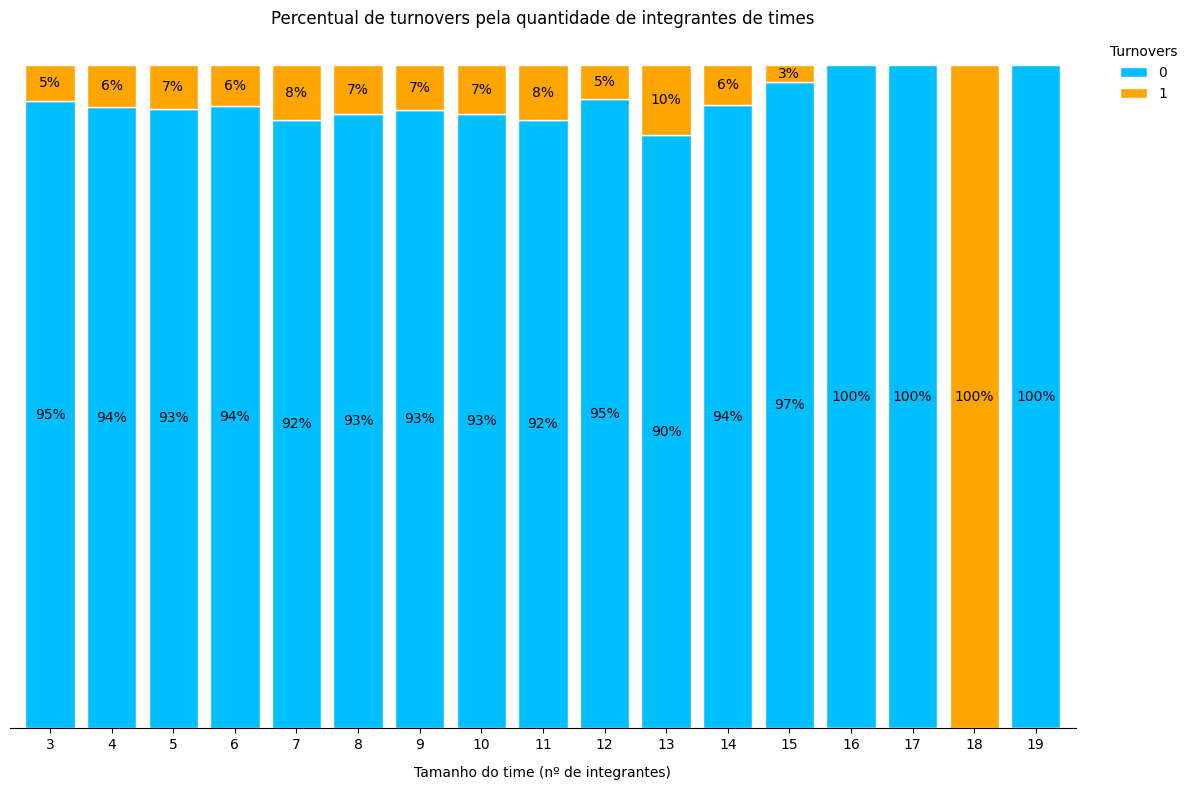

In [248]:
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_tamanho_time, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['deepskyblue', 'orange'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pela quantidade de integrantes de times',
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Tamanho do time (nº de integrantes)', labelpad=10)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=10)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### *A análise demonstra que a Nota de Avaliação não possui correlação com o número de turnovers voluntários*

## Quantidade de Colegas que saíram x Turnover

In [249]:
# Altere para os nomes das variáveis desejadas, sendo uma quantitativa e uma qualitativa (ou quantitativa divididas em faixas)
var_quanti = dados['qtd_colegas_sairam_6m']
var_quali = dados['turnover_voluntario_90d']

In [250]:
# Medidas principais via "describe": média, desvio padrão, mínimo, quartis e máximo
pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
turnover_voluntario_90d,,,,,,,,
0,11179.0,1.143752,1.481924,0.0,0.0,1.0,1.0,10.0
1,821.0,2.323995,2.121268,0.0,1.0,2.0,4.0,10.0


In [251]:
var1 = dados['mudou_de_gestor_12m']
var2 = dados['turnover_voluntario_90d']

pd.crosstab(
    var1,
    var2,
    normalize='index'
).round(3)*100

turnover_voluntario_90d,0,1
mudou_de_gestor_12m,,
nao,94.8,5.2
sim,88.9,11.1


In [252]:
var_quanti = dados['qtd_colegas_sairam_6m']
var_quali = dados['turnover_voluntario_90d']

pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
turnover_voluntario_90d,,,,,,,,
0,11179.0,1.143752,1.481924,0.0,0.0,1.0,1.0,10.0
1,821.0,2.323995,2.121268,0.0,1.0,2.0,4.0,10.0


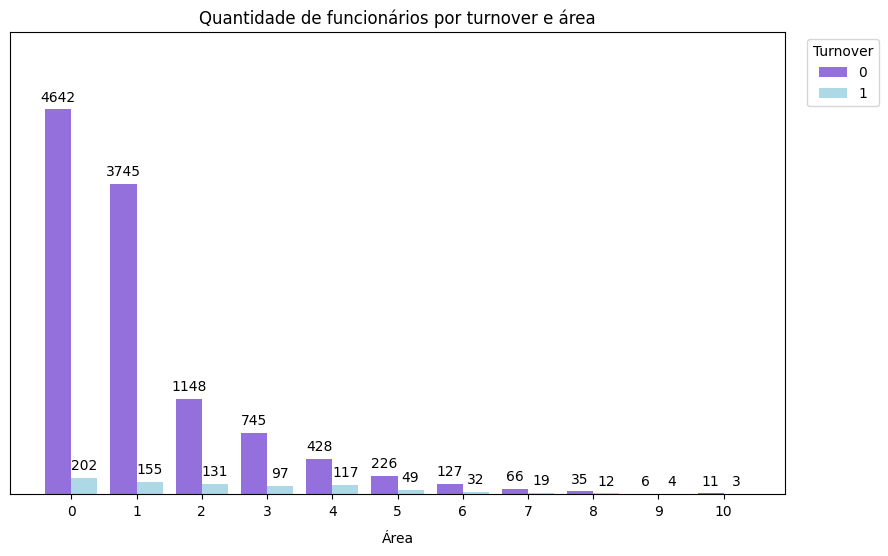

In [253]:
# Tabela de frequências
tab_abs = graph_turnover.groupby(graph_qtd_colegas_sairam_6m, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.8 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(10, 6))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['mediumpurple', 'lightblue']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de funcionários por turnover e área")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Área', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Turnover', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 100, str(v), ha='center')

plt.show()

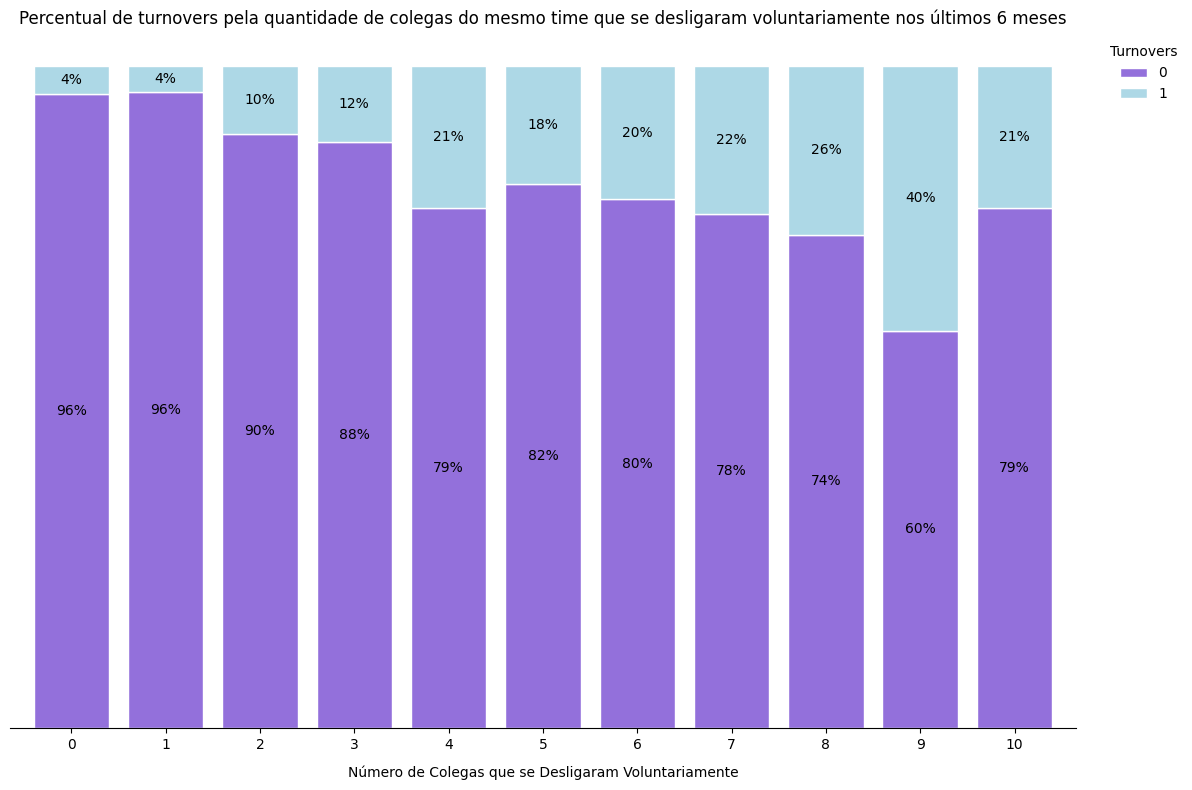

In [254]:
# Tabela de frequências e plotagem
ax = pd.crosstab(graph_qtd_colegas_sairam_6m, graph_turnover, dropna=True, normalize='index').plot(
        kind='bar',
        stacked=True,
        color=['mediumpurple', 'lightblue'],
        edgecolor='white',
        width=0.8,
        figsize=(12,8),
        title='Percentual de turnovers pela quantidade de colegas do mesmo time que se desligaram voluntariamente nos últimos 6 meses',
        )

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Remover bordas superior, direita e esquerda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Grade horizontal discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Número de Colegas que se Desligaram Voluntariamente', labelpad=10)

# Rótulos sobre as barras (ignora valores iguais a 0%)
for bar in ax.containers:
    labels = [
        f'{v.get_height() * 100:.0f}%'
        if v.get_height() > 0 else ''
        for v in bar
    ]
    plt.bar_label(bar, labels=labels, label_type='center', fontsize=10)

# Legenda fora da área de plotagem
plt.legend(
    title='Turnovers',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### *A análise demonstra que a quantidade de colegas do mesmo times que se desligaram voluntariamente influencia altamente no turnover voluntário. Isso ocorre pois existe uma relação proporcional: quanto maior a quantidade de colegas do mesmo time do trabalhador que se desligaram voluntariamente, maior é a taxa de turnover voluntário*

## Análises Adicionais

In [255]:
var1 = dados['nivel_senioridade']
var2 = dados['salario_mensal']
pontos_corte = [var2.min(), 10000, 15000, 23000, var2.max()]
var_quanti_faixas = pd.cut(var2, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
pd.crosstab(var_quanti_faixas, var1, dropna=False, margins=True, margins_name='Total')
pd.crosstab(var_quanti_faixas, var1, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

nivel_senioridade,junior,pleno,senior,gerente,gerente sr./diretor,Total
salario_mensal,,,,,,
"(2999.999, 10000.0]",19.1,9.6,0.1,0.0,0.0,28.7
"(10000.0, 15000.0]",0.1,18.6,3.8,0.0,0.0,22.6
"(15000.0, 23000.0]",0.0,2.1,21.0,1.8,0.0,24.8
"(23000.0, 67300.0]",0.0,0.0,5.9,11.0,6.9,23.9
Total,19.2,30.2,30.8,12.8,6.9,100.0


In [256]:
var1 = dados['nivel_senioridade']
var2 = dados['idade']
pontos_corte = [var2.min(), 27, 35, 43, var2.max()]
var_quanti_faixas = pd.cut(var2, bins=pontos_corte, include_lowest=True)
var_quanti_faixas.value_counts(dropna=False, sort=False)
pd.crosstab(var_quanti_faixas, var1, dropna=False, margins=True, margins_name='Total')
pd.crosstab(var_quanti_faixas, var1, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

nivel_senioridade,junior,pleno,senior,gerente,gerente sr./diretor,Total
idade,,,,,,
"(19.999, 27.0]",10.8,7.9,3.1,0.7,0.1,22.5
"(27.0, 35.0]",7.5,16.3,14.2,4.1,1.8,43.8
"(35.0, 43.0]",0.7,4.7,9.3,4.9,3.0,22.6
"(43.0, 63.0]",0.2,1.4,4.2,3.2,2.1,11.0
Total,19.2,30.2,30.8,12.8,6.9,100.0


# Análises Trivariadas e Multivariadas

In [257]:
print("--- RESUMO DO SALÁRIO POR SENIORIDADE E TURNOVER ---")
# O observed=False garante que o Pandas mostre todas as categorias na ordem, mesmo se houver alguma vazia

# Usando o .describe() para trazer todas as principais medidas estatísticas
tabela_salario = dados.groupby(['nivel_senioridade', 'turnover_voluntario_90d'], observed=False)['salario_mensal'].describe().round(2)

display(tabela_salario)

--- RESUMO DO SALÁRIO POR SENIORIDADE E TURNOVER ---


count      mean       std  \
nivel_senioridade   turnover_voluntario_90d                               
junior              0                        2078.0   6038.02   1301.87   
                    1                         224.0   5704.91   1289.22   
pleno               0                        3351.0  11419.01   2413.67   
                    1                         278.0  10384.17   2206.46   
senior              0                        3491.0  19571.84   4105.89   
                    1                         203.0  18173.40   4066.41   
gerente             0                        1463.0  30178.67   6601.83   
                    1                          79.0  28846.84   6382.50   
gerente sr./diretor 0                         796.0  38354.52   7688.10   
                    1                          37.0  37089.19  10091.33   

                                                 min      25%      50%  \
nivel_senioridade   turnover_voluntario_90d                              
junior              0                         3000.0   5100.0   5900.0   
                    1                         3000.0   4800.0   5600.0   
pleno               0                         4800.0   9800.0  11300.0   
                    1                         5200.0   8900.0  10200.0   
senior              0                         8600.0  16700.0  19200.0   
                    1                         9600.0  15400.0  17600.0   
gerente             0                        13900.0  25550.0  29700.0   
                    1                        14600.0  24150.0  28000.0   
gerente sr./diretor 0                        23200.0  32700.0  37500.0   
                    1                        24800.0  29500.0  34700.0   

                                                 75%      max  
nivel_senioridade   turnover_voluntario_90d                    
junior              0                         6875.0  11300.0  
                    1                         6600.0   9100.0  
pleno               0                        12900.0  26600.0  
                    1                        11700.0  18000.0  
senior              0                        22100.0  40000.0  
                    1                        20350.0  31900.0  
gerente             0                        34400.0  59200.0  
                    1                        33550.0  41900.0  
gerente sr./diretor 0                        43300.0  63200.0  
                    1                        41600.0  67300.0

In [258]:
print("--- SALÁRIO POR SEXO, SENIORIDADE ---")
tabela_sexo = dados.groupby(['sexo', 'nivel_senioridade'], observed=False)['salario_mensal'].describe().round(2)
display(tabela_sexo)

--- SALÁRIO POR SEXO, SENIORIDADE ---


count      mean      std      min      25%  \
sexo nivel_senioridade                                                  
F    junior                982.0   5995.62  1297.08   3000.0   5100.0   
     pleno                1535.0  11306.78  2430.86   4800.0   9600.0   
     senior               1510.0  19558.54  4060.76   9400.0  16700.0   
     gerente               626.0  30191.85  6700.06  14600.0  25500.0   
     gerente sr./diretor   340.0  38155.29  8033.89  23200.0  32400.0   
M    junior               1320.0   6013.03  1309.75   3000.0   5100.0   
     pleno                2094.0  11363.90  2401.67   5100.0   9700.0   
     senior               2184.0  19451.05  4153.36   8600.0  16500.0   
     gerente               916.0  30054.80  6525.84  13900.0  25400.0   
     gerente sr./diretor   493.0  38396.96  7653.66  23500.0  32800.0   

                              50%      75%      max  
sexo nivel_senioridade                               
F    junior                5900.0   6800.0  11100.0  
     pleno                11100.0  12800.0  26600.0  
     senior               19100.0  22100.0  34200.0  
     gerente              29600.0  34300.0  57000.0  
     gerente sr./diretor  37050.0  43225.0  67300.0  
M    junior                5900.0   6800.0  11300.0  
     pleno                11200.0  12800.0  22500.0  
     senior               19100.0  22000.0  40000.0  
     gerente              29700.0  34400.0  59200.0  
     gerente sr./diretor  37600.0  43400.0  61700.0

In [259]:
print("--- FREQUÊNCIA ABSOLUTA: SENIORIDADE E PROMOÇÃO X TURNOVER ---")
tabela_tri_promocao = pd.crosstab(
    index=[dados['nivel_senioridade'], dados['promocao_12m']],
    columns=dados['turnover_voluntario_90d']
)
tabela_tri_promocao.columns = ['Qtd - Ficou (0)', 'Qtd - Saiu (1)']
display(tabela_tri_promocao)

print("\n--- TAXA DE TURNOVER: SENIORIDADE E PROMOÇÃO X TURNOVER ---")
# O normalize='index' calcula a porcentagem por linha, revelando a taxa exata de saída
tabela_tri_promocao_perc = (pd.crosstab(
    index=[dados['nivel_senioridade'], dados['promocao_12m']],
    columns=dados['turnover_voluntario_90d'],
    normalize='index'
) * 100).round(2)
tabela_tri_promocao_perc.columns = ['Taxa de Permanência (%)', 'Taxa de Saída (%)']
display(tabela_tri_promocao_perc)

--- FREQUÊNCIA ABSOLUTA: SENIORIDADE E PROMOÇÃO X TURNOVER ---


Qtd - Ficou (0)  Qtd - Saiu (1)
nivel_senioridade   promocao_12m                                 
junior              nao                      2045             224
                    sim                        33               0
pleno               nao                      3057             262
                    sim                       294              16
senior              nao                      2124             136
                    sim                      1367              67
gerente             nao                       456              31
                    sim                      1007              48
gerente sr./diretor nao                       143               6
                    sim                       653              31


--- TAXA DE TURNOVER: SENIORIDADE E PROMOÇÃO X TURNOVER ---


Taxa de Permanência (%)  Taxa de Saída (%)
nivel_senioridade   promocao_12m                                            
junior              nao                             90.13               9.87
                    sim                            100.00               0.00
pleno               nao                             92.11               7.89
                    sim                             94.84               5.16
senior              nao                             93.98               6.02
                    sim                             95.33               4.67
gerente             nao                             93.63               6.37
                    sim                             95.45               4.55
gerente sr./diretor nao                             95.97               4.03
                    sim                             95.47               4.53

In [260]:
print("--- PERFIL DO COLABORADOR: TEMPO DE CASA E IDADE POR STATUS DE TURNOVER ---")
tabela_perfil_turnover = dados.groupby('turnover_voluntario_90d')[['tempo_empresa_meses', 'idade']].describe().round(2)

display(tabela_perfil_turnover)

--- PERFIL DO COLABORADOR: TEMPO DE CASA E IDADE POR STATUS DE TURNOVER ---


tempo_empresa_meses                                 \
                                      count   mean    std  min   25%   50%   
turnover_voluntario_90d                                                      
0                                   11179.0  32.47  22.42  1.0  14.0  28.0   
1                                     821.0  30.15  19.70  1.0  13.0  30.0   

                                        idade                                 \
                          75%    max    count   mean   std   min   25%   50%   
turnover_voluntario_90d                                                        
0                        46.0  120.0  11179.0  33.67  7.65  20.0  28.0  32.0   
1                        44.0  117.0    821.0  32.46  7.63  21.0  27.0  31.0   

                                     
                          75%   max  
turnover_voluntario_90d              
0                        38.0  63.0  
1                        36.0  63.0

In [261]:
print("--- DIAGNÓSTICO COMPLETO: PERFIL x TURNOVER (ENPS, SALÁRIO) ---")

# 1. Cria faixas para a nota de desempenho (ajuste os cortes conforme a regra da empresa)
dados['faixa_enps'] = pd.cut(
    dados['nota_enps'],
    bins=[-1, 6, 8, 10], # -1 garante que o 0 seja incluído
    labels=['1. (0 a 6)', '2. (7 a 8)', '3. (9 a 10)']
)

# 2. Agrupa usando a nova faixa em vez da nota exata
tabela_mestra = dados.groupby(
    ['nivel_senioridade', 'faixa_enps', 'turnover_voluntario_90d'],
    observed=True
)[['salario_mensal']].mean().round(2)

# 3. Desempilha e reorganiza
tabela_mestra = tabela_mestra.unstack('turnover_voluntario_90d').fillna('-')
tabela_mestra = tabela_mestra.swaplevel(axis=1).sort_index(axis=1)

# 4. (Opcional) Adiciona uma corzinha para facilitar a leitura no Colab
display(
    tabela_mestra.style
    .format(precision=2, na_rep='-')
    .background_gradient(cmap='Blues', axis=0)
)

--- DIAGNÓSTICO COMPLETO: PERFIL x TURNOVER (ENPS, SALÁRIO) ---


In [262]:
print("--- DIAGNÓSTICO: PERFIL x REGIME DE TRABALHO x TURNOVER ---")

# 1. Agrupa usando o regime de trabalho diretamente (arredondando o dado original para 2)
tabela_mestra = dados.groupby(
    ['nivel_senioridade', 'regime_trabalho', 'turnover_voluntario_90d'],
    observed=True
)[['salario_mensal']].mean().round(2)

# 2. Desempilha e reorganiza (repare que tirei o fillna daqui)
tabela_mestra = tabela_mestra.unstack('turnover_voluntario_90d')
tabela_mestra = tabela_mestra.swaplevel(axis=1).sort_index(axis=1)

# 3. Aplica a cor e trava a formatação visual em 2 casas decimais e nulos como traço
display(
    tabela_mestra.style
    .format(precision=2, na_rep='-')
    .background_gradient(cmap='Blues', axis=0)
)

--- DIAGNÓSTICO: PERFIL x REGIME DE TRABALHO x TURNOVER ---


In [263]:
print("--- DIAGNÓSTICO: PERFIL x MUDOU GESTOR x TURNOVER ---")

# 1. Agrupa usando a mudança de gestor
tabela_mestra = dados.groupby(
    ['nivel_senioridade', 'mudou_de_gestor_12m', 'turnover_voluntario_90d'],
    observed=True
)[['salario_mensal']].mean().round(2)

# 2. Desempilha e reorganiza (repare que tirei o fillna daqui)
tabela_mestra = tabela_mestra.unstack('turnover_voluntario_90d')
tabela_mestra = tabela_mestra.swaplevel(axis=1).sort_index(axis=1)

# 3. Aplica a cor e trava a formatação visual em 2 casas decimais e nulos como traço
display(
    tabela_mestra.style
    .format(precision=2, na_rep='-')
    .background_gradient(cmap='Blues', axis=0)
)

--- DIAGNÓSTICO: PERFIL x MUDOU GESTOR x TURNOVER ---


In [264]:
print("--- DIAGNÓSTICO COMPLETO: PERFIL x ENPS x TURNOVER ---")

# 1. Cria faixas para a nota eNPS baseadas no padrão de mercado
dados['faixa_enps'] = pd.cut(
    dados['nota_enps'],
    bins=[-1, 6, 8, 10], # -1 garante que o 0 seja incluído
    labels=['1. (0 a 6)', '2. (7 a 8)', '3. (9 a 10)']
)

# 2. Agrupa usando a faixa de eNPS e aplica funções diferentes para números e textos
tabela_mestra = dados.groupby(
    ['nivel_senioridade', 'faixa_enps', 'turnover_voluntario_90d'],
    observed=True
).agg(
    qtd_colegas_sairam_6m=('qtd_colegas_sairam_6m', 'mean'),
    salario_mensal=('salario_mensal', 'mean'),
    regime_trabalho_comum=('regime_trabalho', lambda x: x.mode()[0] if not x.empty else '-')
)

# 3. Desempilha e reorganiza
tabela_mestra = tabela_mestra.unstack('turnover_voluntario_90d').fillna('-')
tabela_mestra = tabela_mestra.swaplevel(axis=1).sort_index(axis=1)

# 4. Exibe a tabela final
display(
    tabela_mestra.style
    .format(precision=2, na_rep='-')
    .background_gradient(cmap='Blues', axis=0)
)

--- DIAGNÓSTICO COMPLETO: PERFIL x ENPS x TURNOVER ---


*Comparação de medidas resumo*

In [265]:
# Altere para os nomes das variáveis desejadas, sendo uma quantitativa e uma qualitativa (ou quantitativa divididas em faixas)
var_quanti = dados['turnover_voluntario_90d']
var_quali = dados['promocao_12m']
pd.DataFrame(var_quanti.groupby(var_quali).describe())

,count,mean,std,min,25%,50%,75%,max
promocao_12m,,,,,,,,
nao,8484.0,0.077676,0.267676,0.0,0.0,0.0,0.0,1.0
sim,3516.0,0.046075,0.209678,0.0,0.0,0.0,0.0,1.0


## Mudança de Gestor x Turnover

In [266]:
# Altere para os nomes das variáveis desejadas, sendo ambas qualitativas, ou quantitativas divididas em faixas
var1 = dados['mudou_de_gestor_12m']
var2 = dados['turnover_voluntario_90d']

In [267]:
# Tabela de frequências absolutas de dupla entrada
pd.crosstab(var1, var2, dropna=False, margins=True, margins_name='Total')

turnover_voluntario_90d,0,1,Total
mudou_de_gestor_12m,,,
nao,8280,458,8738
sim,2899,363,3262
Total,11179,821,12000


In [268]:
# Tabela de frequências relativas de dupla entrada, no formato de porcentagens, somando 100% no total geral
pd.crosstab(var1, var2, dropna=False, normalize=True, margins=True, margins_name='Total').round(3) * 100

turnover_voluntario_90d,0,1,Total
mudou_de_gestor_12m,,,
nao,69.0,3.8,72.8
sim,24.2,3.0,27.2
Total,93.2,6.8,100.0


### **9. Visualização de dados**

#### **Gráfico de barras simples**

In [269]:
# Altere para o nome da variável desejada
graph1 = dados['tempo_no_cargo_meses']
graph2 = dados['promocao_12m']
graph3 = dados['salario_mensal']
graph4 = dados['perc_bonus_ultimo_ciclo']
graph5 = dados['turnover_voluntario_90d']

*Versão formatada*

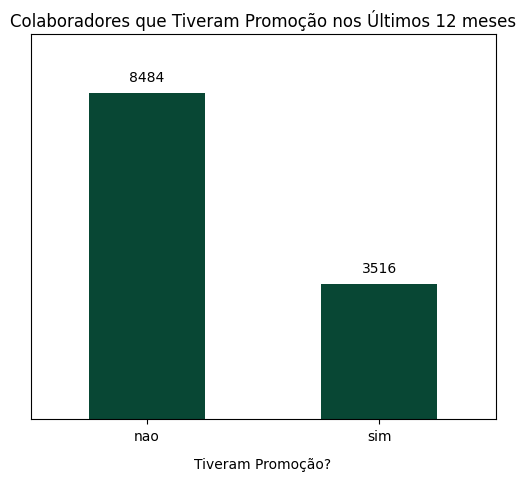

In [270]:
# Tabela de frequências
tab_abs = graph2.value_counts(dropna=False).sort_index()

# Tamanho da figura e plotagem
plt.figure(figsize=(6, 5))
tab_abs.plot(kind='bar', color='#084734')

# Título do gráfico
plt.title("Colaboradores que Tiveram Promoção nos Últimos 12 meses")

# Limites do eixo vertical
plt.ylim(0, 10000)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Orientação do texto do eixo horizontal
plt.xticks(rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Tiveram Promoção?', labelpad=10)

# Rótulos sobre as barras
for i, v in enumerate(tab_abs):
    plt.text(i, v + 300, str(v), ha='center')

plt.show()

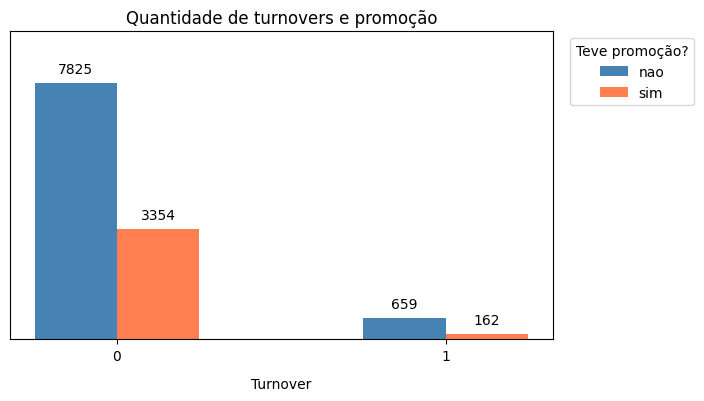

In [271]:
# Tabela de frequências
tab_abs = graph2.groupby(graph5, observed=True).value_counts(dropna=True).unstack().fillna(0).astype(int)

fluxos  = tab_abs.columns
bairros = tab_abs.index
x       = np.arange(len(bairros))

# Largura de cada barra
largura = 0.5 / len(fluxos)

# Tamanho da figura e plotagem
plt.figure(figsize=(7, 4))
for i, fluxo in enumerate(fluxos):
    valores = tab_abs[fluxo]
    cores = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod']
    plt.bar(x + i * largura, valores, largura, label=fluxo, color=cores[i])

# Título do gráfico
plt.title("Quantidade de turnovers e promoção")

# Limites do eixo vertical
plt.ylim(0, tab_abs.values.max() * 1.2)

# Ocultar eixo vertical
plt.gca().get_yaxis().set_visible(False)

# Posicionamento e orientação do texto do eixo horizontal
plt.xticks(x + largura * (len(fluxos) - 1) / 2, bairros, rotation=0)

# Título do eixo horizontal e espaçamento
plt.xlabel('Turnover', labelpad=10)

# Legenda fora da área de plotagem
plt.legend(title='Teve promoção?', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rótulos sobre as barras
for i, fluxo in enumerate(fluxos):
    for j, v in enumerate(tab_abs[fluxo]):
        plt.text(j + i * largura, v + 300, str(v), ha='center')

plt.show()

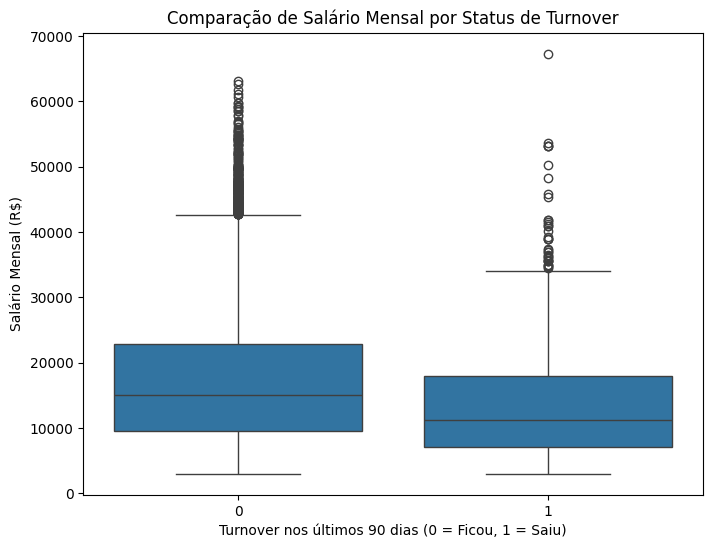

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho da figura
plt.figure(figsize=(8, 6))

# Criando o Boxplot bivariado
# x: variável categórica (Turnover), y: variável numérica (Salário)
sns.boxplot(x='turnover_voluntario_90d', y='salario_mensal', data=dados)

# Customizando os títulos
plt.title('Comparação de Salário Mensal por Status de Turnover')
plt.xlabel('Turnover nos últimos 90 dias (0 = Ficou, 1 = Saiu)')
plt.ylabel('Salário Mensal (R$)')

# Exibindo o gráfico direto na tela do Colab
plt.show()

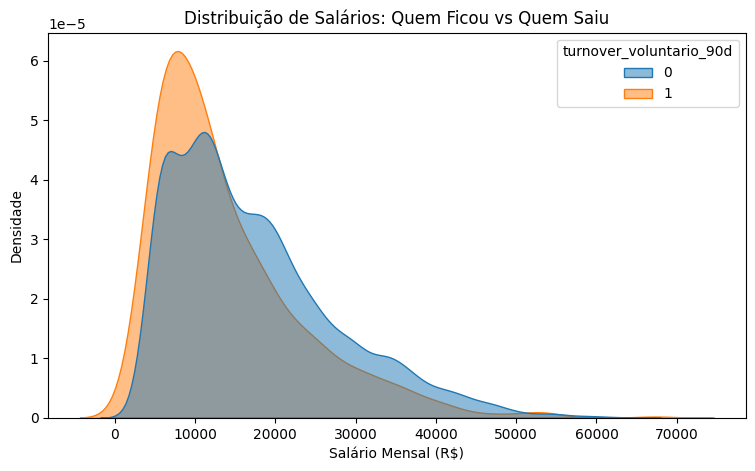

In [273]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=dados, x='salario_mensal', hue='turnover_voluntario_90d', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribuição de Salários: Quem Ficou vs Quem Saiu')
plt.xlabel('Salário Mensal (R$)')
plt.ylabel('Densidade')
plt.show()

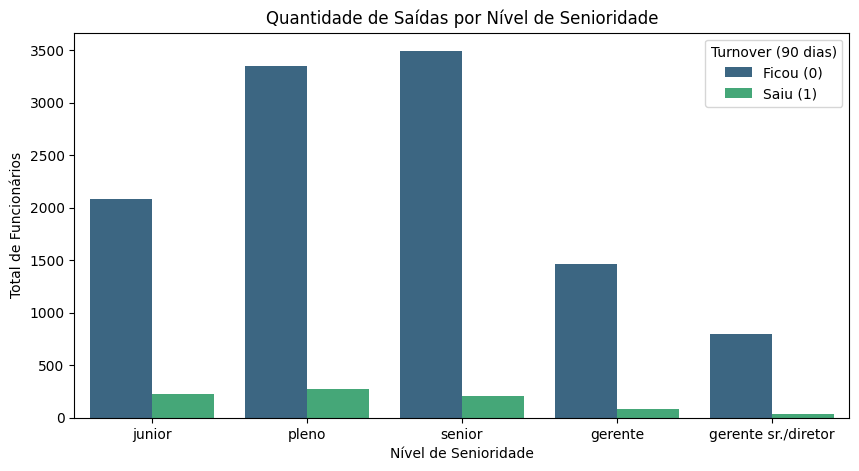

In [274]:
plt.figure(figsize=(10, 5))
# Como a coluna agora é categórica, o Seaborn já desenha na ordem certa
sns.countplot(data=dados, x='nivel_senioridade', hue='turnover_voluntario_90d', palette='viridis')

plt.title('Quantidade de Saídas por Nível de Senioridade')
plt.xlabel('Nível de Senioridade')
plt.ylabel('Total de Funcionários')
plt.legend(title='Turnover (90 dias)', labels=['Ficou (0)', 'Saiu (1)'])
plt.show()

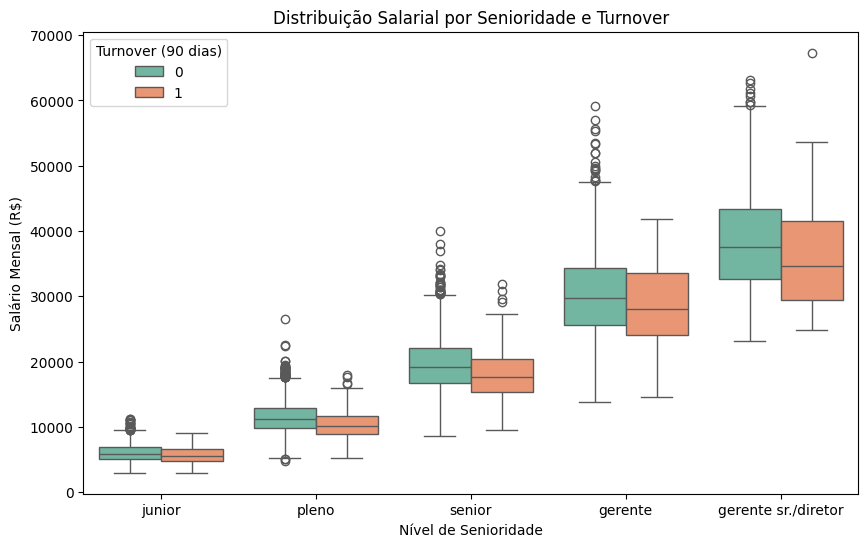

In [275]:
plt.figure(figsize=(10, 6))
# O parâmetro 'order' força o Seaborn a desenhar as caixas na sequência correta
sns.boxplot(
    data=dados, x='nivel_senioridade', y='salario_mensal',
    hue='turnover_voluntario_90d', palette='Set2',
    order=ordem_senioridade
)
plt.title('Distribuição Salarial por Senioridade e Turnover')
plt.xlabel('Nível de Senioridade')
plt.ylabel('Salário Mensal (R$)')
plt.legend(title='Turnover (90 dias)')
plt.show()

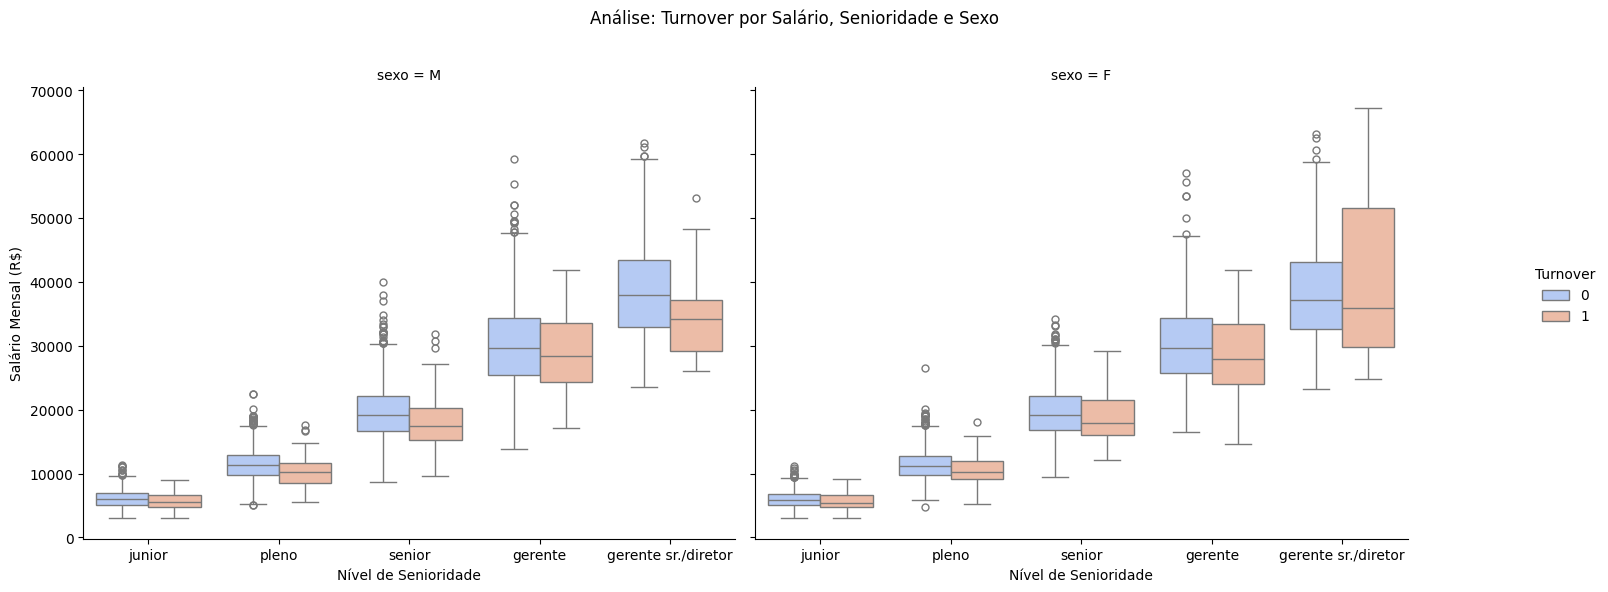

In [276]:
g = sns.catplot(
    data=dados, x='nivel_senioridade', y='salario_mensal',
    hue='turnover_voluntario_90d', col='sexo',
    kind='box', palette='coolwarm', height=6, aspect=1.2,
    order=ordem_senioridade # Forçando a ordem aqui
)
g.set_axis_labels("Nível de Senioridade", "Salário Mensal (R$)")
g.legend.set_title("Turnover")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análise: Turnover por Salário, Senioridade e Sexo')
plt.show()

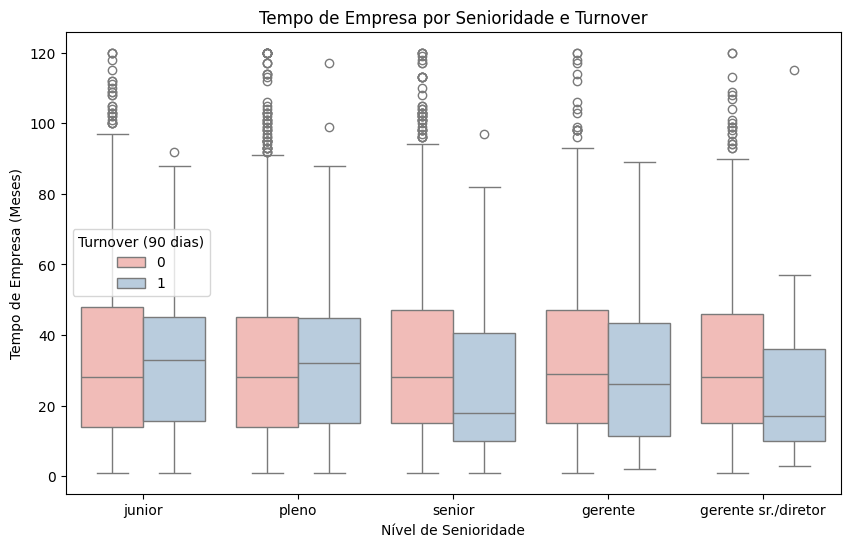

In [277]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=dados, x='nivel_senioridade', y='tempo_empresa_meses',
    hue='turnover_voluntario_90d', palette='Pastel1',
    order=ordem_senioridade
)
plt.title('Tempo de Empresa por Senioridade e Turnover')
plt.xlabel('Nível de Senioridade')
plt.ylabel('Tempo de Empresa (Meses)')
plt.legend(title='Turnover (90 dias)')
plt.show()

# *As maiores correlações com as quantidades de Turnover ocorrem nas colunas de Regime de Trabalho, Nota do ENPS, Mudança de Gestor 12m, Percentual de Bônus último ciclo e Quantidade de colegas que sairam nos últimos 6m.*